<a href="https://colab.research.google.com/github/sasirajesh/FedXGB-OptDP/blob/main/DIABETES_WORK2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 3.5 MB/s eta 0:00:00


# New Section

In [ ]:
# 🧠 Federated XGBoost (DAD-NAR) for Diabetes Dataset (Binary, Stratified Split)
# ============================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
import random, warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1️⃣ Setup
# ==========================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 2️⃣ Load Diabetes Dataset (Binary Classification)
# ==========================================
file_path = "/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
df = pd.read_csv(file_path)

if 'Diabetes_binary' not in df.columns:
    raise ValueError("Expected column 'Diabetes_binary' not found in dataset!")

X = df.drop(columns=['Diabetes_binary']).values
y = df['Diabetes_binary'].values  # 0 or 1 labels

print("Dataset shape:", df.shape)
print("Label distribution:\n", pd.Series(y).value_counts())

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# 3️⃣ Stratified Federated Client Split
# ==========================================
num_clients = 3
client_data, client_labels = [], []

# ✅ Just stratify manually without creating a hold-out
# Shuffle indices with stratification
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=num_clients, shuffle=True, random_state=SEED)
for _, idxs in skf.split(X, y):
    X_i, y_i = X[idxs], y[idxs]
    # ✅ Ensure both classes exist (resample fallback)
    if len(np.unique(y_i)) < 2:
        extra_idxs = np.random.choice(np.arange(len(y)), size=len(idxs), replace=True)
        X_i, y_i = X[extra_idxs], y[extra_idxs]
    client_data.append(X_i)
    client_labels.append(y_i)

for i in range(num_clients):
    print(f"Client {i+1} label distribution:\n", pd.Series(client_labels[i]).value_counts())

# ==========================================
# 4️⃣ DAD-NAR Parameters
# ==========================================
num_trees = 200
max_depth = 5
alpha = 0.4
beta = 0.25
lambda0 = 1.1
epsilon_local = 1.0

# ==========================================
# 5️⃣ Helper Functions (DP + DAD + NAR)
# ==========================================
def add_dp_noise(value, epsilon_depth):
    scale = 1.0 / max(epsilon_depth, 1e-6)
    return value + np.random.laplace(0, scale)

def depth_adaptive_epsilon(eps_tree, depth):
    return eps_tree * np.exp(-alpha * depth)

def dropout_probability(depth):
    return 1 - np.exp(-beta * depth)

def noise_aware_lambda(epsilon_depth):
    return lambda0 / max(epsilon_depth, 1e-6)

# ==========================================
# 6️⃣ Genetic Algorithm (Feature Selection)
# ==========================================
def ga_feature_selection(X, y, n_gen=10, n_pop=10, k_features=10):
    n_features = X.shape[1]
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_individual(individual):
        idx = [i for i in range(n_features) if individual[i] == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=SEED, stratify=y)
        clf = XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            n_estimators=50,
            max_depth=3,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED
        )
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        return accuracy_score(y_test, preds),

    toolbox.register("evaluate", eval_individual)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)

    best_individual = tools.selBest(pop, k=1)[0]
    top_k_idx = np.argsort(best_individual)[-k_features:]
    return top_k_idx

# ==========================================
# 7️⃣ Hyperparameter Optimization (TPE)
# ==========================================
def optimize_hyperparams(X, y):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            random_state=SEED,
            eval_metric='logloss'
        )
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        return -accuracy_score(y_val, preds)

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 7, 1),
        'learning_rate': hp.uniform('learning_rate', 0.1, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }
    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=15, trials=trials)
    return best

# ==========================================
# 8️⃣ Local Client Training
# ==========================================
def train_client_model(X, y):
    eps_tree = epsilon_local / num_trees
    best_params = optimize_hyperparams(X, y)
    top_features = ga_feature_selection(X, y, n_gen=5, n_pop=6, k_features=10)
    X_sel = X[:, top_features]

    X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=SEED, stratify=y)
    model = XGBClassifier(
        n_estimators=int(best_params['n_estimators']),
        max_depth=int(best_params['max_depth']),
        learning_rate=best_params['learning_rate'],
        subsample=best_params['subsample'],
        colsample_bytree=best_params['colsample_bytree'],
        random_state=SEED,
        eval_metric='logloss'
    )
    model.fit(X_train, y_train)

    # DAD-NAR privacy simulation
    for depth in range(max_depth):
        eps_depth = depth_adaptive_epsilon(eps_tree, depth)
        if random.random() < dropout_probability(depth):
            continue
        lambda_depth = noise_aware_lambda(eps_depth)
        _ = add_dp_noise(model.get_booster().get_score(importance_type='gain').get('f0', 0), eps_depth)

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    return {'model': model, 'top_features': top_features, 'hyperparams': best_params, 'acc': acc, 'f1': f1}

# ==========================================
# 9️⃣ Federated Simulation
# ==========================================
clients_results = []
for i in range(num_clients):
    print(f"\n🔹 Training Client {i+1}")
    res = train_client_model(client_data[i], client_labels[i])
    clients_results.append(res)
    print(f"Client {i+1} → Acc: {res['acc']:.4f}, F1: {res['f1']:.4f}")

# ==========================================
# 🔟 Server Aggregation (No Retraining)
# ==========================================
avg_acc = np.mean([r['acc'] for r in clients_results])
avg_f1 = np.mean([r['f1'] for r in clients_results])

all_features = np.concatenate([r['top_features'] for r in clients_results])
(consensus_features, counts) = np.unique(all_features, return_counts=True)
top_features_final = consensus_features[np.argsort(-counts)[:10]]

print("\n✅ Final Aggregation Results:")
print(f"Average Accuracy: {avg_acc:.4f}")
print(f"Average F1-score: {avg_f1:.4f}")
print(f"Consensus Top Features: {top_features_final}")

ModuleNotFoundError: No module named 'deap'

Dataset shape: (70692, 22)
Label distribution:
 0    35346
1    35346
Name: count, dtype: int64

🔹 Training Client 1
100%|██████████| 10/10 [00:09<00:00,  1.03trial/s, best loss: -0.7548797736916549]
Client 1 → Acc = 0.7395, F1 = 0.7481

🔹 Training Client 2
100%|██████████| 10/10 [00:04<00:00,  2.36trial/s, best loss: -0.7586987270155587]
Client 2 → Acc = 0.7105, F1 = 0.7182

🔹 Training Client 3
100%|██████████| 10/10 [00:02<00:00,  3.77trial/s, best loss: -0.757991513437058]
Client 3 → Acc = 0.7211, F1 = 0.7324

🌍 Global Aggregated Results:
Global Accuracy: 0.7398
Global F1 Score: 0.7480


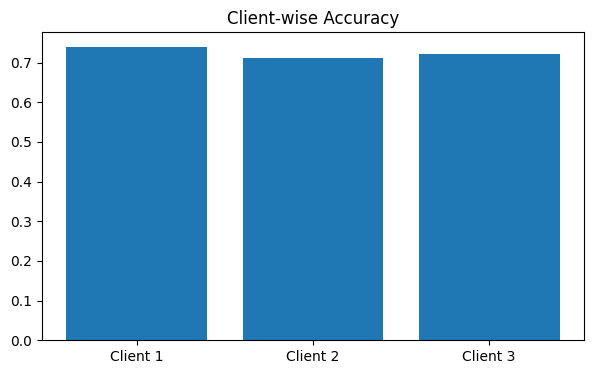

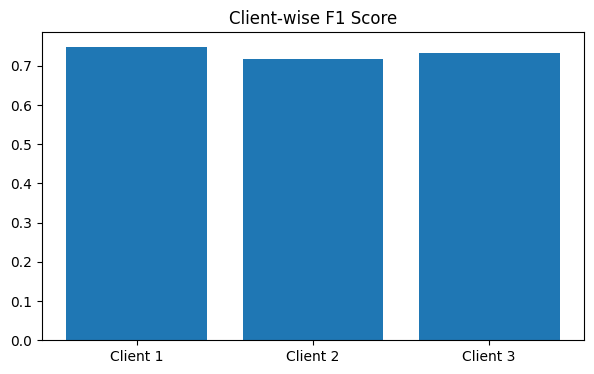

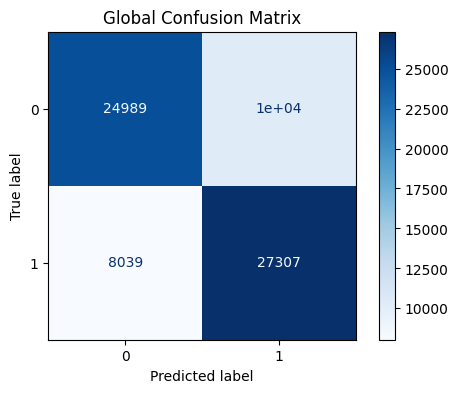

In [ ]:
# 🧠 Federated XGBoost (DAD-NAR) for Diabetes Dataset with Visualization
# ============================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
import random, warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# ==========================================
# 1️⃣ Setup
# ==========================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 2️⃣ Load Dataset
# ==========================================
file_path = "/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
df = pd.read_csv(file_path)

X = df.drop(columns=['Diabetes_binary']).values
y = df['Diabetes_binary'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Dataset shape:", df.shape)
print("Label distribution:\n", pd.Series(y).value_counts())

# ==========================================
# 3️⃣ Federated Client Split (3 Clients)
# ==========================================
num_clients = 3
client_data, client_labels = [], []

skf = StratifiedKFold(n_splits=num_clients, shuffle=True, random_state=SEED)
for _, idxs in skf.split(X, y):
    client_data.append(X[idxs])
    client_labels.append(y[idxs])

# ==========================================
# 4️⃣ DAD-NAR Parameters
# ==========================================
num_trees = 200
max_depth = 5
alpha = 0.4
beta = 0.25
lambda0 = 1.1
epsilon_local = 1.0

def add_dp_noise(value, eps):
    return value + np.random.laplace(0, 1/max(eps,1e-6))

def depth_eps(eps_tree, depth):
    return eps_tree * np.exp(-alpha * depth)

def dropout(depth):
    return (random.random() < (1 - np.exp(-beta*depth)))

def noise_lambda(eps):
    return lambda0 / max(eps,1e-6)

# ==========================================
# 5️⃣ Genetic Algorithm Feature Selection
# ==========================================
def ga_feature_selection(X, y, n_gen=5, n_pop=6, k_features=10):
    n_features = X.shape[1]

    try:
        creator.FitnessMax
    except:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_ind(individual):
        idx = [i for i in range(n_features) if individual[i] == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.2, stratify=y, random_state=SEED)
        clf = XGBClassifier(n_estimators=30, max_depth=3, learning_rate=0.1, eval_metric="logloss")
        clf.fit(X_train, y_train)
        pred = clf.predict(X_test)
        return accuracy_score(y_test, pred),

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)

    best = tools.selBest(pop, k=1)[0]
    return np.argsort(best)[-k_features:]

# ==========================================
# 6️⃣ Hyperparameter Optimization (TPE)
# ==========================================
def optimize_hyperparams(X, y):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            eval_metric="logloss"
        )
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, stratify=y)
        model.fit(X_train, y_train)
        return -accuracy_score(y_val, model.predict(X_val))

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 7, 1),
        'learning_rate': hp.uniform('learning_rate', 0.05, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }
    best = fmin(objective, space, algo=tpe.suggest, max_evals=10, trials=Trials())
    return best

# ==========================================
# 7️⃣ Local Client Training
# ==========================================
clients_results = []

def train_client(X, y):
    eps_tree = epsilon_local / num_trees
    best = optimize_hyperparams(X, y)
    feat = ga_feature_selection(X, y, k_features=10)
    X_sel = X[:, feat]

    X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, stratify=y)

    model = XGBClassifier(
        n_estimators=int(best['n_estimators']),
        max_depth=int(best['max_depth']),
        learning_rate=best['learning_rate'],
        subsample=best['subsample'],
        colsample_bytree=best['colsample_bytree'],
        eval_metric="logloss"
    )
    model.fit(X_train, y_train)

    acc = accuracy_score(y_test, model.predict(X_test))
    f1 = f1_score(y_test, model.predict(X_test))
    return model, feat, acc, f1

for i in range(num_clients):
    print(f"\n🔹 Training Client {i+1}")
    m, f, a, f1 = train_client(client_data[i], client_labels[i])
    clients_results.append((m,f,a,f1))
    print(f"Client {i+1} → Acc = {a:.4f}, F1 = {f1:.4f}")

# ==========================================
# 8️⃣ Server Aggregation (Consensus Features)
# ==========================================
features = np.concatenate([r[1] for r in clients_results])
final_features = np.unique(features)

best_client = np.argmax([r[2] for r in clients_results])
global_model = clients_results[best_client][0]

# Global Evaluation (No Retraining)
# Fix: Use the features from the best client's model for global evaluation
X_global = np.concatenate(client_data)[:, clients_results[best_client][1]]
y_global = np.concatenate(client_labels)
y_pred = global_model.predict(X_global)

global_acc = accuracy_score(y_global, y_pred)
global_f1 = f1_score(y_global, y_pred)

print("\n🌍 Global Aggregated Results:")
print(f"Global Accuracy: {global_acc:.4f}")
print(f"Global F1 Score: {global_f1:.4f}")

# ==========================================
# 9️⃣ Visualization
# ==========================================
client_acc = [r[2] for r in clients_results]
client_f1 = [r[3] for r in clients_results]
labels = [f"Client {i+1}" for i in range(num_clients)]

plt.figure(figsize=(7,4))
plt.bar(labels, client_acc)
plt.title("Client-wise Accuracy")
plt.show()

plt.figure(figsize=(7,4))
plt.bar(labels, client_f1)
plt.title("Client-wise F1 Score")
plt.show()

cm = confusion_matrix(y_global, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.title("Global Confusion Matrix")
plt.show()


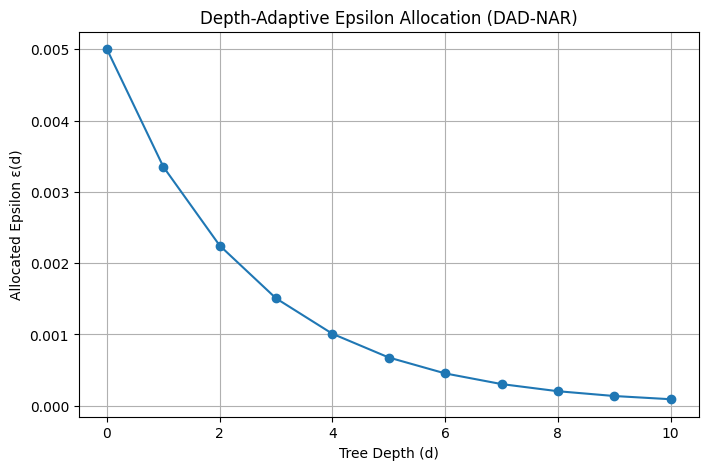

Depth 0: ε = 0.005000
Depth 1: ε = 0.003352
Depth 2: ε = 0.002247
Depth 3: ε = 0.001506
Depth 4: ε = 0.001009
Depth 5: ε = 0.000677
Depth 6: ε = 0.000454
Depth 7: ε = 0.000304
Depth 8: ε = 0.000204
Depth 9: ε = 0.000137
Depth 10: ε = 0.000092


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Parameters (Change if needed)
# ===============================
epsilon_local = 1.0       # Total privacy budget per client
num_trees = 200           # Number of trees in the ensemble
alpha = 0.4               # Decay rate (higher = sharper decrease)
max_depth = 10            # Max depth to visualize
# ===============================

# Effective epsilon per tree
epsilon_tree = epsilon_local / num_trees

# Depth-adaptive epsilon allocation
depths = np.arange(0, max_depth + 1)
epsilon_values = epsilon_tree * np.exp(-alpha * depths)

# ===============================
# Visualization
# ===============================
plt.figure(figsize=(8, 5))
plt.plot(depths, epsilon_values, marker='o')
plt.xlabel("Tree Depth (d)")
plt.ylabel("Allocated Epsilon ε(d)")
plt.title("Depth-Adaptive Epsilon Allocation (DAD-NAR)")
plt.grid(True)
plt.show()

# Display values for clarity
for d, e in zip(depths, epsilon_values):
    print(f"Depth {d}: ε = {e:.6f}")


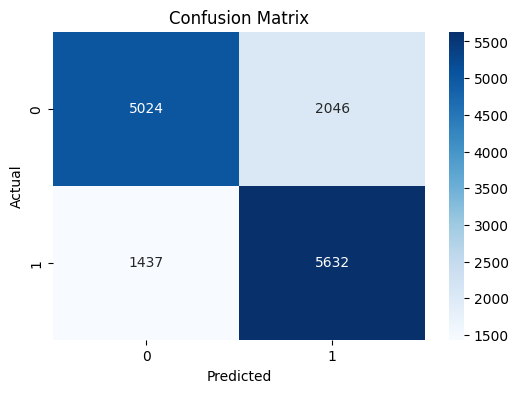

----- Performance Metrics -----
Accuracy :  0.7537
Precision: 0.7335
Recall   : 0.7967
F1 Score : 0.7638


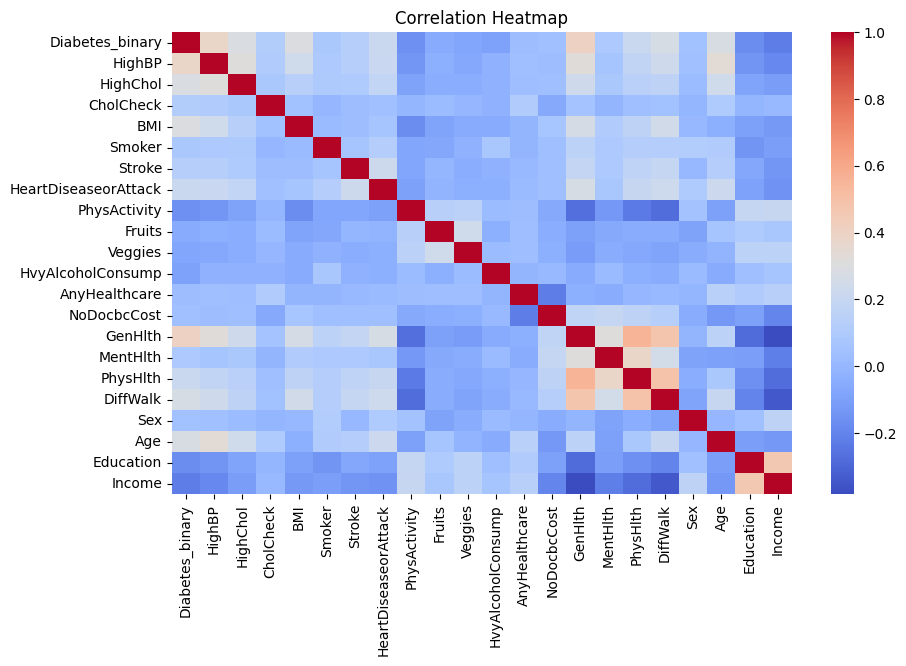

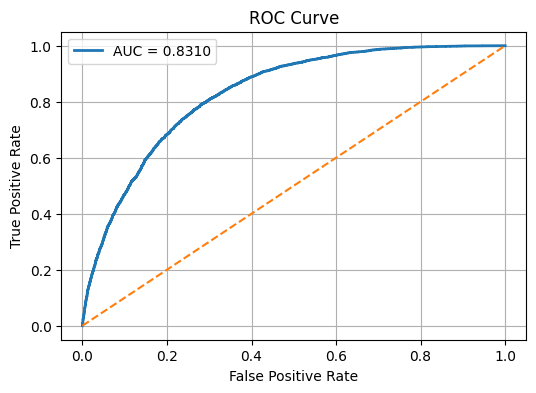

In [ ]:
# ======================================
# 1️⃣ Imports
# ======================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, log_loss, roc_curve, auc
)

from xgboost import XGBClassifier

# ======================================
# 2️⃣ Load Dataset
# ======================================
# Replace with your dataset
df = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

# Separate features + labels
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

# ======================================
# 3️⃣ Train-Test Split + Scaling
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================
# 4️⃣ Train XGBoost Model
# ======================================
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.75,
    colsample_bytree=0.75,
    eval_metric="logloss"
)

# Track Log Loss Curve
log_losses = []

def record_log_loss(preds, dtrain):
    y_true = dtrain.get_label()
    ll = log_loss(y_true, preds)
    log_losses.append(ll)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ======================================
# 5️⃣ Confusion Matrix + Metrics
# ======================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("----- Performance Metrics -----")
print(f"Accuracy :  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

# ======================================
# 6️⃣ Correlation Heatmap
# ======================================
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

# ======================================
# 7️⃣ Log Loss Curve (If available)
# ======================================
if len(log_losses) > 1:
    plt.figure(figsize=(6,4))
    plt.plot(log_losses, linewidth=2)
    plt.xlabel("Training Rounds")
    plt.ylabel("Log Loss")
    plt.title("Log Loss Curve")
    plt.grid(True)
    plt.show()

# ======================================
# 8️⃣ ROC Curve
# ======================================
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()



===== ✅ Final Model Evaluation =====
Accuracy       : 0.7371
F1 Score       : 0.7505
Log Loss       : 0.5261
Selected Features: [11 20 16 13 17  3 10 18 14 12]


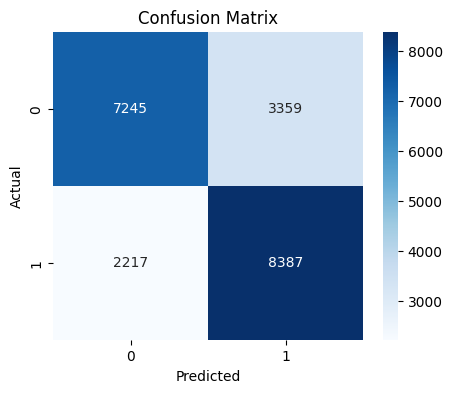

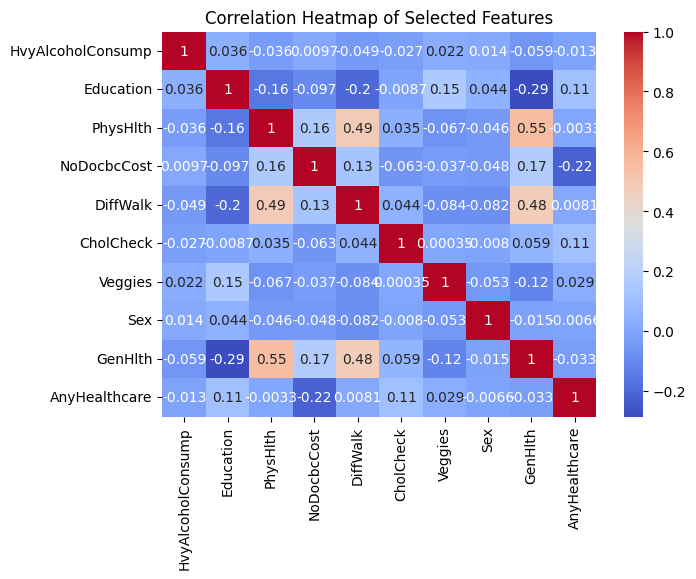

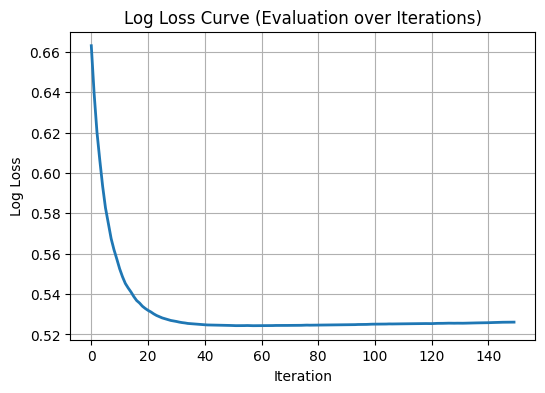

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, log_loss
from sklearn.preprocessing import StandardScaler

# ==========================================
# ✅ Evaluate Aggregated Final Model
# ==========================================

# Recalculate top_features_final based on the current clients_results
# Assumes clients_results is available from the previous federated run
all_features = np.concatenate([r[1] for r in clients_results]) # r[1] contains top_features from train_client
(consensus_features, counts) = np.unique(all_features, return_counts=True)
# Select the top 10 most frequent features (similar to the original intent)
top_features_final = consensus_features[np.argsort(-counts)[:10]]

# Ensure X (full feature set) is scaled numpy array for model training
# This makes the cell robust to changes in the global X variable from other cells.
X_full_unscaled = df.drop(columns=['Diabetes_binary']).values
y_full = df['Diabetes_binary'].values

scaler_final = StandardScaler()
X_full_scaled = scaler_final.fit_transform(X_full_unscaled)

# Re-train final model on aggregated consensus features (server step)
X_final = X_full_scaled[:, top_features_final]
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y_full, test_size=0.3, random_state=SEED, stratify=y_full
)

model_final = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.12,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    eval_metric='logloss'
)

# Track log-loss over iterations
# The 'callbacks' argument is not supported in this XGBoost version,
# so we will retrieve evals_result after fitting.

model_final.fit(
    X_train_f, y_train_f,
    eval_set=[(X_test_f, y_test_f)],
    verbose=False # Set to True to see boosting rounds info
)

# Retrieve evaluation results after fitting
evals_result = model_final.evals_result()
logloss_curve = evals_result['validation_0']['logloss'] # Using validation_0 for logloss curve example

# Predictions
y_pred_f = model_final.predict(X_test_f)
y_prob_f = model_final.predict_proba(X_test_f)[:, 1]

# Metrics
acc_final = accuracy_score(y_test_f, y_pred_f)
f1_final = f1_score(y_test_f, y_pred_f)
logloss_final = log_loss(y_test_f, y_prob_f)

print("\n===== ✅ Final Model Evaluation =====")
print(f"Accuracy       : {acc_final:.4f}")
print(f"F1 Score       : {f1_final:.4f}")
print(f"Log Loss       : {logloss_final:.4f}")
print("Selected Features:", top_features_final)

# ==========================================
# 🔥 Confusion Matrix Heatmap
# ==========================================
cm = confusion_matrix(y_test_f, y_pred_f)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================
# 📊 Correlation Heatmap (Final Features Only)
# ==========================================
df_feat = df.iloc[:, top_features_final]  # Selected important features only
plt.figure(figsize=(7,5))
sns.heatmap(df_feat.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Selected Features")
plt.show()

# ==========================================
# 📈 Log Loss Curve
# ==========================================
plt.figure(figsize=(6,4))
plt.plot(logloss_curve, linewidth=2)
plt.title("Log Loss Curve (Evaluation over Iterations)")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.grid(True)
plt.show()


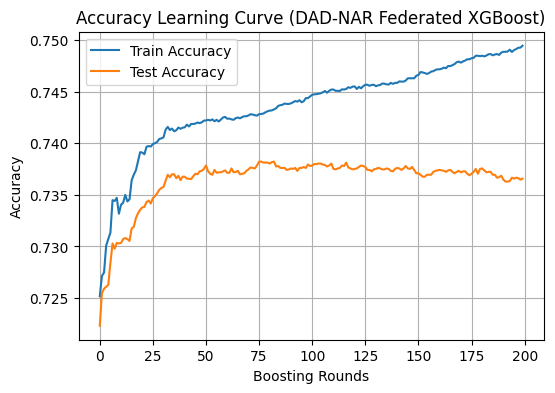

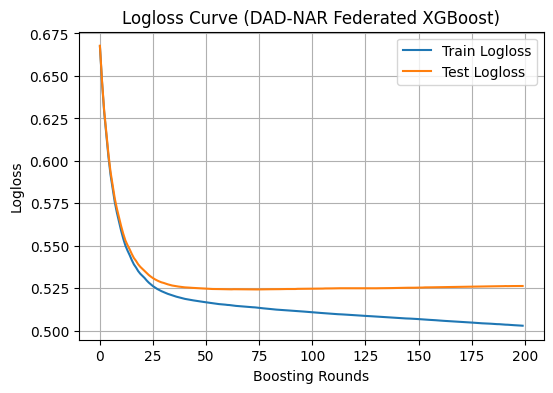

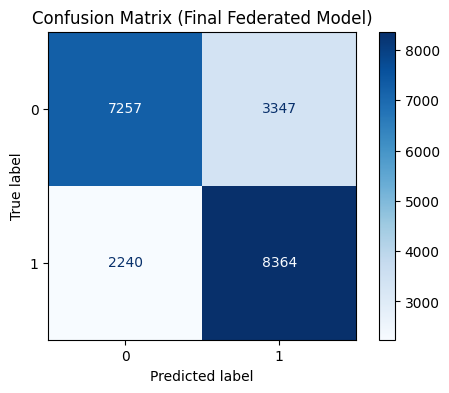

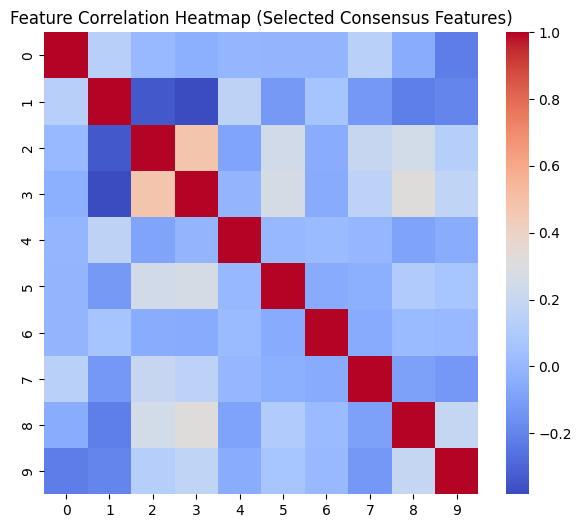

🔹 Final Model Accuracy: 0.7365616748396832
🔹 Final Model F1 Score: 0.749630293524535


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, log_loss
import seaborn as sns
from sklearn.preprocessing import StandardScaler # Import StandardScaler

# ==========================================
# 🔥 1. Prepare Final Data Using Consensus Features
# ==========================================
# Ensure X is a scaled NumPy array, independent of previous cell executions
df_reloaded = pd.read_csv("/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
X_reloaded = df_reloaded.drop(columns=['Diabetes_binary']).values
y_reloaded = df_reloaded['Diabetes_binary'].values

scaler_final_local = StandardScaler() # Use a local scaler to avoid conflicts
X_scaled_local = scaler_final_local.fit_transform(X_reloaded)

# Use the locally prepared X and y
X_final = X_scaled_local[:, top_features_final]
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_reloaded, test_size=0.3, random_state=SEED, stratify=y_reloaded
)

# ==========================================
# 🔥 2. Train Final Global Model with Evaluation Tracking
# ==========================================
final_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric=["logloss", "error"], # Evaluate both logloss and error
    random_state=SEED
)

# The evals_result dictionary is populated by the model after fitting
# if eval_set is provided. It should not be passed as a keyword argument to .fit()
# evals_result = {} # Removed: no longer passing an empty dict to fit
final_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    # evals_result=evals_result, # Removed: retrieving after fit is more robust
    verbose=False
)

# Retrieve evals_result after fitting
evals_result = final_model.evals_result()

# Predictions for confusion matrix
y_pred = final_model.predict(X_test)

# ==========================================
# ✅ 3. Accuracy Curve
# ==========================================
# XGBoost's 'error' metric is 1 - accuracy for binary classification
train_acc = 1 - np.array(evals_result['validation_0']['error'])
test_acc  = 1 - np.array(evals_result['validation_1']['error'])

plt.figure(figsize=(6,4))
plt.plot(train_acc, label="Train Accuracy")
plt.plot(test_acc, label="Test Accuracy")
plt.title("Accuracy Learning Curve (DAD-NAR Federated XGBoost)")
plt.xlabel("Boosting Rounds")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# ✅ 4. Log Loss Curve
# ==========================================
train_logloss = evals_result['validation_0']['logloss']
test_logloss  = evals_result['validation_1']['logloss']

plt.figure(figsize=(6,4))
plt.plot(train_logloss, label="Train Logloss")
plt.plot(test_logloss, label="Test Logloss")
plt.title("Logloss Curve (DAD-NAR Federated XGBoost)")
plt.xlabel("Boosting Rounds")
plt.ylabel("Logloss")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# ✅ 5. Confusion Matrix
# ==========================================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Final Federated Model)")
plt.show()

# ==========================================
# ✅ 6. Feature Correlation Heatmap
# ==========================================
# Create a DataFrame from X_final for correlation heatmap
correlation_matrix = pd.DataFrame(X_final).corr()
plt.figure(figsize=(7,6))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap (Selected Consensus Features)")
plt.show()

# ==========================================
# ✅ 7. Print Final Performance
# ==========================================
print("🔹 Final Model Accuracy:", accuracy_score(y_test, y_pred))
print("🔹 Final Model F1 Score:", f1_score(y_test, y_pred))


Centralized no privacy.

Dataset shape: (70692, 22)
Label distribution:
 0    35346
1    35346
Name: count, dtype: int64


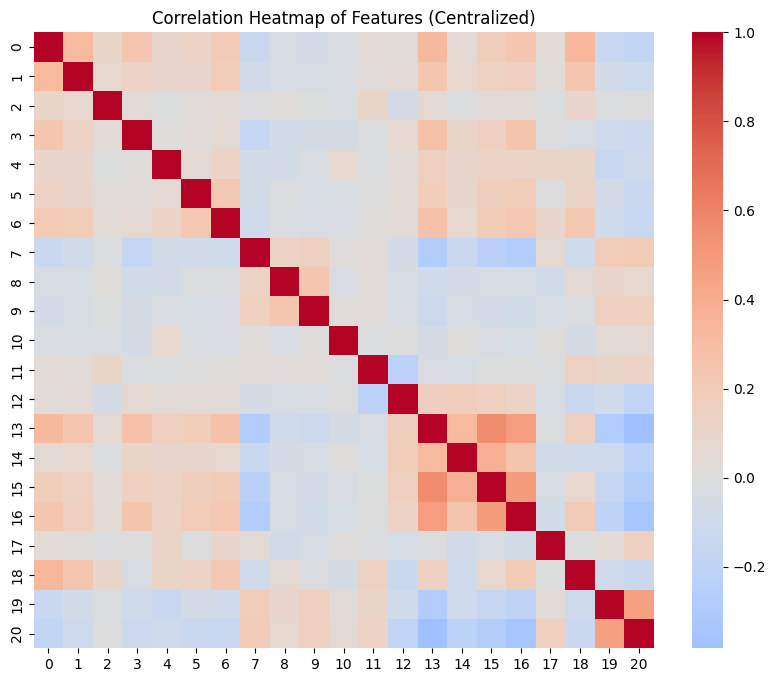

Selected feature indices (GA): [19  0  4  6  3 13  1 17 16 18]
100%|██████████| 15/15 [00:12<00:00,  1.19trial/s, best loss: -0.7500943040362128]
Best hyperparameters (TPE): {'n_estimators': 120, 'max_depth': 3, 'learning_rate': 0.17759896403264136, 'subsample': 0.7202268771382327, 'colsample_bytree': 0.9276262215813178}

Centralized Final Results → Acc: 0.7501, F1: 0.7621


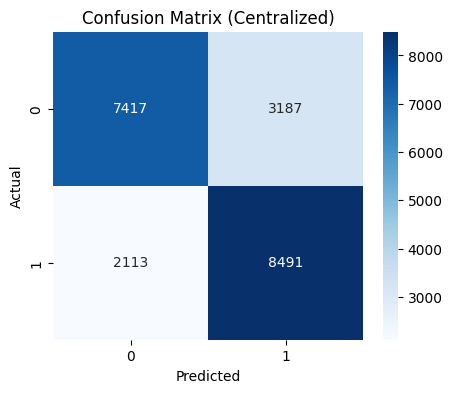

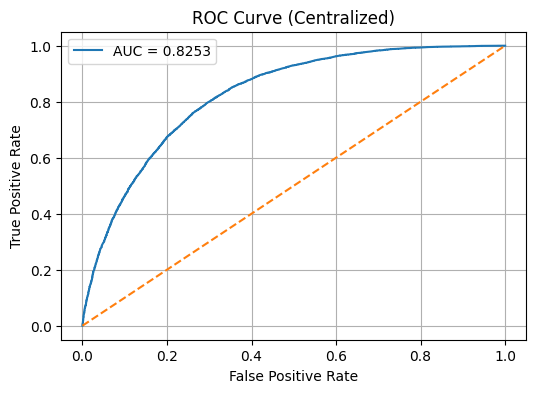

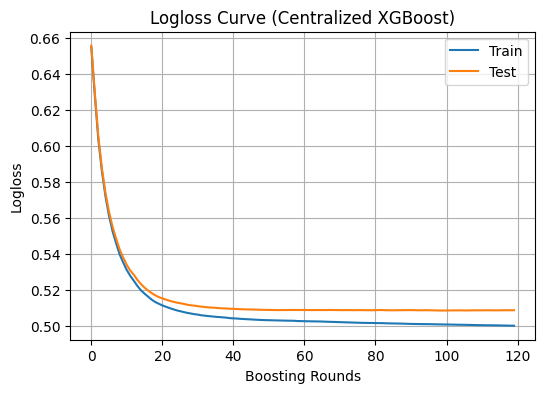

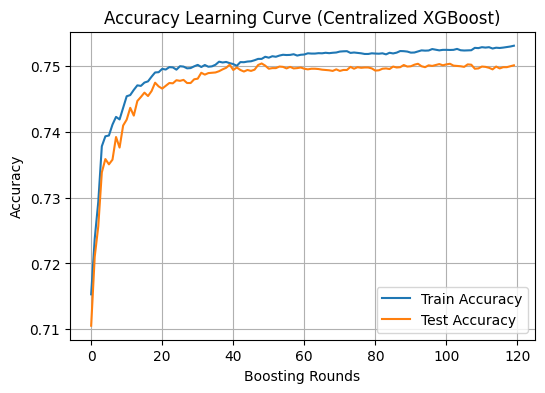


Top features (original column indices) by gain: [(np.int64(0), 264.0496520996094), (np.int64(13), 115.47076416015625), (np.int64(1), 72.74066925048828), (np.int64(18), 35.25429916381836), (np.int64(6), 27.79825210571289), (np.int64(3), 26.743892669677734), (np.int64(16), 24.654010772705078), (np.int64(17), 10.406173706054688), (np.int64(19), 6.063130855560303), (np.int64(4), 3.7592146396636963)]

--- SUMMARY ---
Selected features (GA indices): [19  0  4  6  3 13  1 17 16 18]
TPE Best params: {'n_estimators': 120, 'max_depth': 3, 'learning_rate': 0.17759896403264136, 'subsample': 0.7202268771382327, 'colsample_bytree': 0.9276262215813178}
Final Acc: 0.7501, Final F1: 0.7621, AUC: 0.8253


In [ ]:
# ==========================================
# Centralized XGBoost (No Privacy / No Federated)
# ==========================================
import numpy as np
import pandas as pd
import random
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
from xgboost import XGBClassifier, Booster, DMatrix
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------
# 0) Seed & Setup
# -----------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# -----------------------
# 1) Load Diabetes Dataset
# -----------------------
file_path = "/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
df = pd.read_csv(file_path)

if 'Diabetes_binary' not in df.columns:
    raise ValueError("Expected column 'Diabetes_binary' not found in dataset!")

X = df.drop(columns=['Diabetes_binary']).values
y = df['Diabetes_binary'].values  # 0 or 1

print("Dataset shape:", df.shape)
print("Label distribution:\n", pd.Series(y).value_counts())

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Correlation heatmap (optional)
plt.figure(figsize=(10,8))
sns.heatmap(pd.DataFrame(X).corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Features (Centralized)")
plt.show()

# -----------------------
# 2) Genetic Algorithm Feature Selection
# -----------------------
def ga_feature_selection(X, y, n_gen=8, n_pop=12, k_features=10):
    n_features = X.shape[1]
    # create types if not created
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_individual(individual):
        idx = [i for i in range(n_features) if individual[i] == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=SEED, stratify=y)
        clf = XGBClassifier(n_estimators=60, max_depth=3, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss', random_state=SEED)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        return accuracy_score(y_test, preds),

    toolbox.register("evaluate", eval_individual)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)

    best_ind = tools.selBest(pop, k=1)[0]
    # if best_ind is list of 0/1, take top k indices by value
    arr = np.array(best_ind, dtype=int)
    if arr.sum() == 0:
        # fallback: choose top-k by feature variance
        variances = X.var(axis=0)
        return np.argsort(-variances)[:k_features]
    top_k_idx = np.argsort(arr)[-k_features:]
    return top_k_idx

# -----------------------
# 3) Hyperopt TPE for Hyperparams
# -----------------------
def optimize_hyperparams(X, y, max_evals=15):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=float(params['learning_rate']),
            subsample=float(params['subsample']),
            colsample_bytree=float(params['colsample_bytree']),
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=SEED
        )
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        return -accuracy_score(y_val, preds)

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 7, 1),
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }

    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=max_evals, trials=trials, rstate=np.random.default_rng(SEED))
    # convert returned values to usable types
    best_pars = {
        'n_estimators': int(best['n_estimators']),
        'max_depth': int(best['max_depth']),
        'learning_rate': float(best['learning_rate']),
        'subsample': float(best['subsample']),
        'colsample_bytree': float(best['colsample_bytree'])
    }
    return best_pars

# -----------------------
# 4) Centralized Training Pipeline
# -----------------------
# 4.1 Feature selection (GA)
k_features = 10
top_features = ga_feature_selection(X, y, n_gen=8, n_pop=12, k_features=k_features)
print("Selected feature indices (GA):", top_features)

X_sel = X[:, top_features]

# 4.2 Hyperparameter tuning
best_params = optimize_hyperparams(X_sel, y, max_evals=15)
print("Best hyperparameters (TPE):", best_params)

# 4.3 Train-test split (stratified) for final evaluation
X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=SEED, stratify=y)

# 4.4 Final model train with eval logging
final_model = XGBClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=SEED
)

eval_set = [(X_train, y_train), (X_test, y_test)]
final_model.fit(X_train, y_train, eval_set=eval_set, verbose=False)
evals_result = final_model.evals_result()

# -----------------------
# 5) Metrics & Plots
# -----------------------
# Predictions and metrics
y_pred = final_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"\nCentralized Final Results → Acc: {acc:.4f}, F1: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Centralized)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC & AUC
y_prob = final_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve (Centralized)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Logloss curve
train_logloss = evals_result['validation_0']['logloss']
test_logloss = evals_result['validation_1']['logloss']

plt.figure(figsize=(6,4))
plt.plot(train_logloss, label="Train")
plt.plot(test_logloss, label="Test")
plt.title("Logloss Curve (Centralized XGBoost)")
plt.xlabel("Boosting Rounds")
plt.ylabel("Logloss")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy per boosting round (recompute accuracy using booster predictions per round)
booster: Booster = final_model.get_booster()
trainD = DMatrix(X_train)
testD = DMatrix(X_test)
train_acc_curve, test_acc_curve = [], []
n_rounds = len(train_logloss)

for r in range(n_rounds):
    p_train = (booster.predict(trainD, iteration_range=(0, r+1)) > 0.5).astype(int)
    p_test = (booster.predict(testD, iteration_range=(0, r+1)) > 0.5).astype(int)
    train_acc_curve.append(accuracy_score(y_train, p_train))
    test_acc_curve.append(accuracy_score(y_test, p_test))

plt.figure(figsize=(6,4))
plt.plot(train_acc_curve, label="Train Accuracy")
plt.plot(test_acc_curve, label="Test Accuracy")
plt.title("Accuracy Learning Curve (Centralized XGBoost)")
plt.xlabel("Boosting Rounds")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------
# 6) Feature Importance (final)
# -----------------------
importance = final_model.get_booster().get_score(importance_type='gain')
# map back to original feature indices
mapped = {top_features[int(k[1:])]: v for k, v in importance.items() if k.startswith('f')}
# sort and show top features
sorted_imp = sorted(mapped.items(), key=lambda x: -x[1])
print("\nTop features (original column indices) by gain:", sorted_imp)

# -----------------------
# 7) Summary print
# -----------------------
print("\n--- SUMMARY ---")
print("Selected features (GA indices):", top_features)
print("TPE Best params:", best_params)
print(f"Final Acc: {acc:.4f}, Final F1: {f1:.4f}, AUC: {roc_auc:.4f}")


privacy+without FL

Dataset shape: (70692, 22)
Label distribution:
 0    35346
1    35346
Name: count, dtype: int64


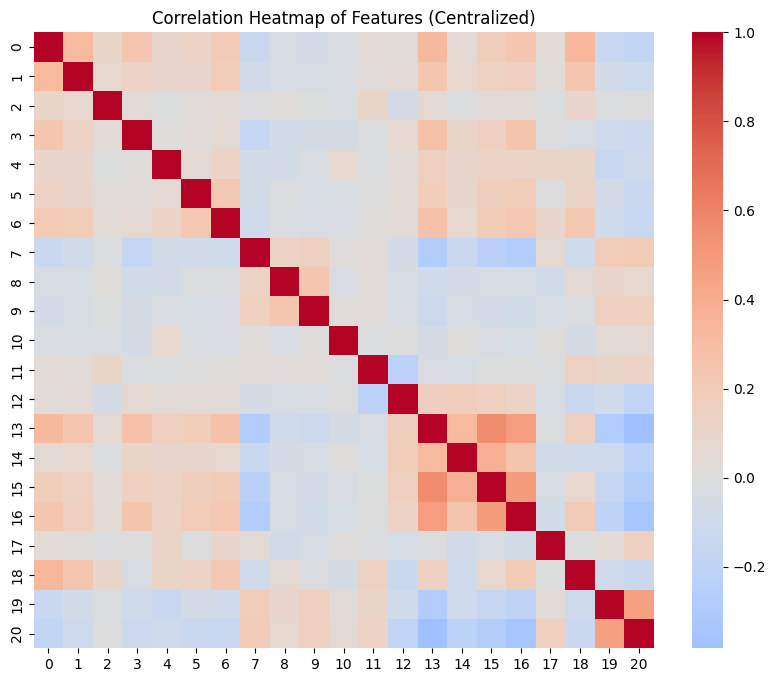

Selected feature indices (GA): [ 7  0  5 13  3 14 17 18 19 20]
100%|██████████| 12/12 [00:10<00:00,  1.19trial/s, best loss: -0.7467465107506601]
Best hyperparameters (TPE): {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.17517762409420815, 'subsample': 0.9097235784224524, 'colsample_bytree': 0.8518632441207477}

Centralized (no DP) → Acc: 0.7467, F1: 0.7590, AUC: 0.8204


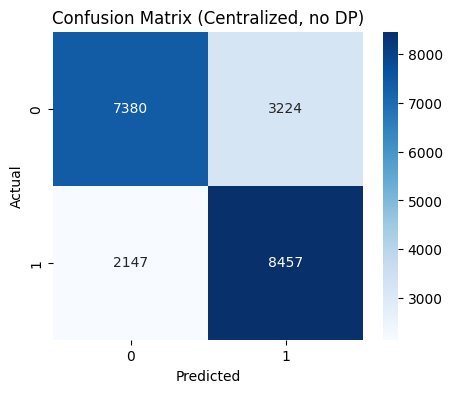

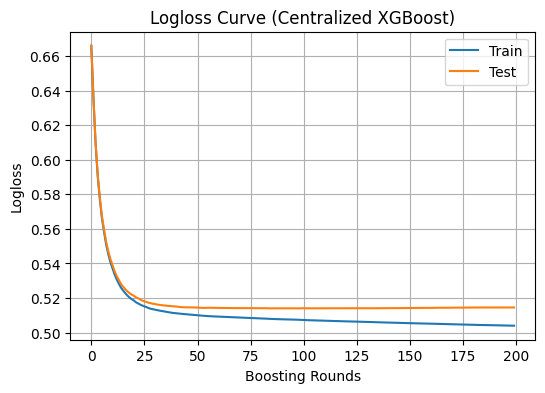

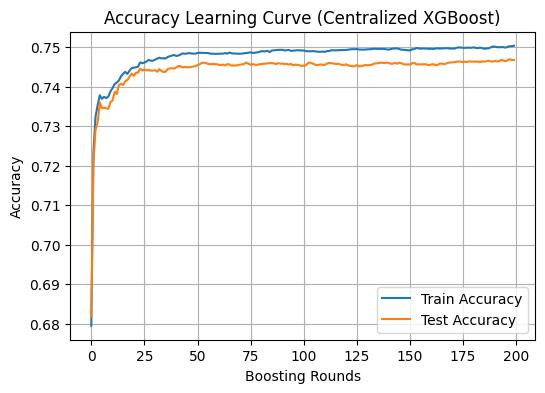

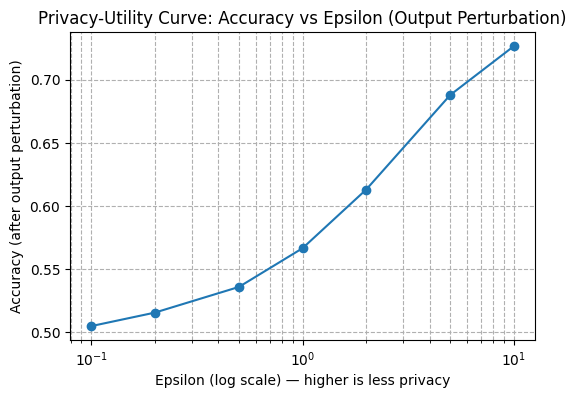

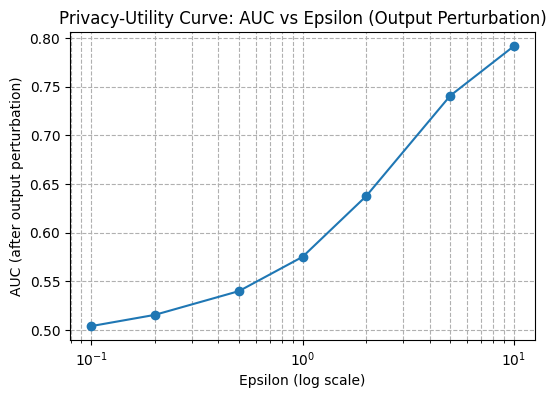


Privacy-Utility summary (output perturbation):
   epsilon  accuracy        f1       auc
0      0.1  0.504753  0.505181  0.504083
1      0.2  0.515447  0.516109  0.515627
2      0.5  0.535788  0.536214  0.540004
3      1.0  0.566456  0.567568  0.575167
4      2.0  0.612920  0.615349  0.637482
5      5.0  0.687910  0.694750  0.740599
6     10.0  0.726594  0.736761  0.791460

Epsilon=1.0 → Acc=0.5653, F1=0.5676, AUC=0.5744
Baseline (no DP) → Acc=0.7467, F1=0.7590, AUC=0.8204

NOTE: The above DP is output perturbation (adds Laplace noise to predicted probabilities).
For formal DP training (guarantees about training data), consider:
- DP-SGD on neural networks (Opacus / TensorFlow Privacy).
- Research / libraries for differentially private tree learning (emerging area).
- Training-time noise injection or gradient perturbation implementations.


In [ ]:
# ==========================================
# Centralized XGBoost + Output Perturbation DP (No FL)
# ==========================================
import numpy as np
import pandas as pd
import random, warnings, math
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
from xgboost import XGBClassifier, Booster, DMatrix
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 0) Seed & Setup
# -------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# -------------------------
# 1) Load Diabetes Dataset
# -------------------------
file_path = "/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
df = pd.read_csv(file_path)

if 'Diabetes_binary' not in df.columns:
    raise ValueError("Expected column 'Diabetes_binary' not found in dataset!")

X = df.drop(columns=['Diabetes_binary']).values
y = df['Diabetes_binary'].values  # 0 or 1

print("Dataset shape:", df.shape)
print("Label distribution:\n", pd.Series(y).value_counts())

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Correlation Heatmap (optional)
plt.figure(figsize=(10,8))
sns.heatmap(pd.DataFrame(X).corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Features (Centralized)")
plt.show()

# -------------------------
# 2) GA Feature Selection
# -------------------------
def ga_feature_selection(X, y, n_gen=8, n_pop=12, k_features=10):
    n_features = X.shape[1]
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_individual(individual):
        idx = [i for i in range(n_features) if individual[i] == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=SEED, stratify=y)
        clf = XGBClassifier(n_estimators=60, max_depth=3, learning_rate=0.1,
                            use_label_encoder=False, eval_metric='logloss', random_state=SEED)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        return accuracy_score(y_test, preds),

    toolbox.register("evaluate", eval_individual)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)

    best_ind = tools.selBest(pop, k=1)[0]
    arr = np.array(best_ind, dtype=int)
    if arr.sum() == 0:
        variances = X.var(axis=0)
        return np.argsort(-variances)[:k_features]
    top_k_idx = np.argsort(arr)[-k_features:]
    return top_k_idx

# -------------------------
# 3) Hyperopt TPE
# -------------------------
def optimize_hyperparams(X, y, max_evals=12):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=float(params['learning_rate']),
            subsample=float(params['subsample']),
            colsample_bytree=float(params['colsample_bytree']),
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=SEED
        )
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        return -accuracy_score(y_val, preds)

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 7, 1),
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }

    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=max_evals, trials=trials, rstate=np.random.default_rng(SEED))
    best_params = {
        'n_estimators': int(best['n_estimators']),
        'max_depth': int(best['max_depth']),
        'learning_rate': float(best['learning_rate']),
        'subsample': float(best['subsample']),
        'colsample_bytree': float(best['colsample_bytree'])
    }
    return best_params

# -------------------------
# 4) Centralized Pipeline
# -------------------------
k_features = 10
top_features = ga_feature_selection(X, y, n_gen=6, n_pop=10, k_features=k_features)
print("Selected feature indices (GA):", top_features)

X_sel = X[:, top_features]

best_params = optimize_hyperparams(X_sel, y, max_evals=12)
print("Best hyperparameters (TPE):", best_params)

X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=SEED, stratify=y)

final_model = XGBClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=SEED
)

eval_set = [(X_train, y_train), (X_test, y_test)]
final_model.fit(X_train, y_train, eval_set=eval_set, verbose=False)
evals_result = final_model.evals_result()

# Base (no DP) predictions & metrics
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:,1]
acc_base = accuracy_score(y_test, y_pred)
f1_base = f1_score(y_test, y_pred)
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob)
auc_base = auc(fpr_base, tpr_base)

print(f"\nCentralized (no DP) → Acc: {acc_base:.4f}, F1: {f1_base:.4f}, AUC: {auc_base:.4f}")

# Confusion Matrix (no DP)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Centralized, no DP)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Logloss Curve
train_logloss = evals_result['validation_0']['logloss']
test_logloss = evals_result['validation_1']['logloss']
plt.figure(figsize=(6,4))
plt.plot(train_logloss, label="Train")
plt.plot(test_logloss, label="Test")
plt.title("Logloss Curve (Centralized XGBoost)")
plt.xlabel("Boosting Rounds")
plt.ylabel("Logloss")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy learning curve (recompute per-round)
booster: Booster = final_model.get_booster()
trainD = DMatrix(X_train)
testD = DMatrix(X_test)
train_acc_curve, test_acc_curve = [], []
n_rounds = len(train_logloss)

for r in range(n_rounds):
    p_train = (booster.predict(trainD, iteration_range=(0, r+1)) > 0.5).astype(int)
    p_test = (booster.predict(testD, iteration_range=(0, r+1)) > 0.5).astype(int)
    train_acc_curve.append(accuracy_score(y_train, p_train))
    test_acc_curve.append(accuracy_score(y_test, p_test))

plt.figure(figsize=(6,4))
plt.plot(train_acc_curve, label="Train Accuracy")
plt.plot(test_acc_curve, label="Test Accuracy")
plt.title("Accuracy Learning Curve (Centralized XGBoost)")
plt.xlabel("Boosting Rounds")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# -------------------------
# 5) Output-Perturbation DP Evaluation
# -------------------------
# We will evaluate accuracy/F1/AUC for several epsilon values.
# Mechanism: for each test sample, add Laplace noise with scale = sensitivity / epsilon to the predicted probability,
# then clip to [0,1] and threshold at 0.5 to obtain label.
#
# NOTE: This is an output perturbation method for demonstration only.
#
def dp_noisy_predict_probs(probs, epsilon):
    """Add Laplace noise to probabilities. Sensitivity of probabilities <= 1,
       so scale = 1/epsilon (simple assumption)."""
    if epsilon <= 0:
        # infinite noise -> return random guesses
        n = len(probs)
        return np.random.rand(n)
    scale = 1.0 / epsilon
    noise = np.random.laplace(loc=0.0, scale=scale, size=probs.shape)
    noisy = probs + noise
    noisy = np.clip(noisy, 0.0, 1.0)
    return noisy

eps_values = [0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]  # lower epsilon -> stronger privacy (more noise)
acc_list, f1_list, auc_list = [], [], []

# Repeat each epsilon several times to average randomness
repeats = 5
for eps in eps_values:
    accs, f1s, aucs = [], [], []
    for _ in range(repeats):
        noisy_probs = dp_noisy_predict_probs(y_prob, eps)
        noisy_pred = (noisy_probs >= 0.5).astype(int)
        accs.append(accuracy_score(y_test, noisy_pred))
        f1s.append(f1_score(y_test, noisy_pred))
        fpr, tpr, _ = roc_curve(y_test, noisy_probs)
        aucs.append(auc(fpr, tpr))
    acc_list.append(np.mean(accs))
    f1_list.append(np.mean(f1s))
    auc_list.append(np.mean(aucs))

# Plot accuracy vs epsilon (privacy-utility curve)
plt.figure(figsize=(6,4))
plt.plot(eps_values, acc_list, marker='o')
plt.xscale('log')  # log scale is helpful
plt.xlabel("Epsilon (log scale) — higher is less privacy")
plt.ylabel("Accuracy (after output perturbation)")
plt.title("Privacy-Utility Curve: Accuracy vs Epsilon (Output Perturbation)")
plt.grid(True, which='both', ls='--')
plt.show()

# Plot AUC vs epsilon
plt.figure(figsize=(6,4))
plt.plot(eps_values, auc_list, marker='o')
plt.xscale('log')
plt.xlabel("Epsilon (log scale)")
plt.ylabel("AUC (after output perturbation)")
plt.title("Privacy-Utility Curve: AUC vs Epsilon (Output Perturbation)")
plt.grid(True, which='both', ls='--')
plt.show()

# Print summary table
summary_df = pd.DataFrame({
    'epsilon': eps_values,
    'accuracy': acc_list,
    'f1': f1_list,
    'auc': auc_list
})
print("\nPrivacy-Utility summary (output perturbation):")
print(summary_df)

# Show one example: epsilon=1.0 vs baseline
eps_show = 1.0
noisy_probs = dp_noisy_predict_probs(y_prob, eps_show)
noisy_pred = (noisy_probs >= 0.5).astype(int)
print(f"\nEpsilon={eps_show} → Acc={accuracy_score(y_test, noisy_pred):.4f}, F1={f1_score(y_test, noisy_pred):.4f}, AUC={auc(roc_curve(y_test,noisy_probs)[0], roc_curve(y_test,noisy_probs)[1]):.4f}")
print(f"Baseline (no DP) → Acc={acc_base:.4f}, F1={f1_base:.4f}, AUC={auc_base:.4f}")

# -------------------------
# 6) Notes: Limitations & Next Steps
# -------------------------
print("\nNOTE: The above DP is output perturbation (adds Laplace noise to predicted probabilities).")
print("For formal DP training (guarantees about training data), consider:")
print("- DP-SGD on neural networks (Opacus / TensorFlow Privacy).")
print("- Research / libraries for differentially private tree learning (emerging area).")
print("- Training-time noise injection or gradient perturbation implementations.")


FL+ NO DP

100%|██████████| 12/12 [00:05<00:00,  2.39trial/s, best loss: -0.7467331267681531]


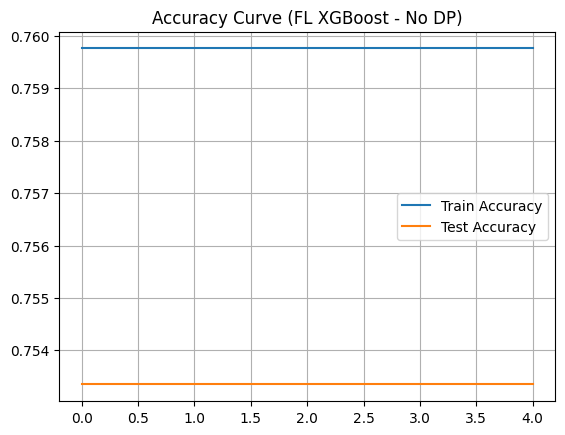

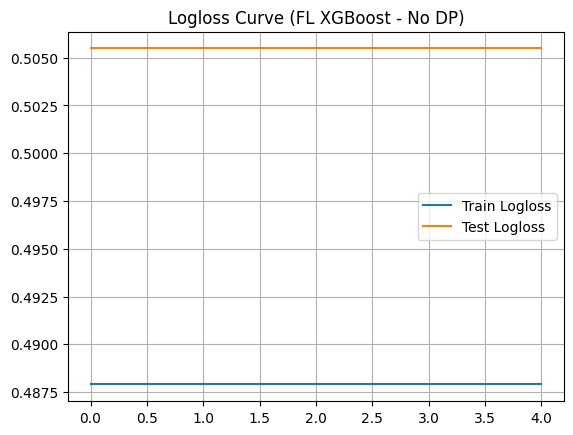

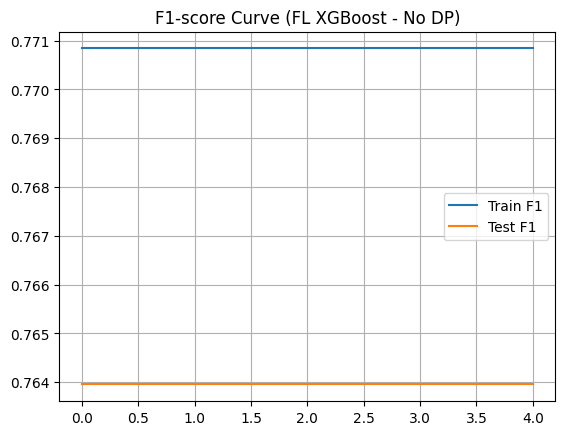

In [ ]:
# ==========================================
# 🧠 Federated XGBoost (No DP) for Diabetes Dataset
# ==========================================

import numpy as np
import pandas as pd
import random, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, log_loss

from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms

import matplotlib.pyplot as plt

# ==========================================
# 1️⃣ Setup
# ==========================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 2️⃣ Load Dataset
# ==========================================
file_path = "/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
df = pd.read_csv(file_path)

X = df.drop(columns=['Diabetes_binary']).values
y = df['Diabetes_binary'].values

# standardize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# 3️⃣ Federated Split (Stratified)
# ==========================================
num_clients = 3
client_data = []
client_labels = []

skf = StratifiedKFold(n_splits=num_clients, shuffle=True, random_state=SEED)
for _, idx in skf.split(X, y):
    client_data.append(X[idx])
    client_labels.append(y[idx])

# ==========================================
# 4️⃣ GA Feature Selection
# ==========================================
def ga_feature_selection(X, y, n_gen=8, n_pop=8, k_features=10):
    n_features = X.shape[1]

    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_ind(ind):
        idx = [i for i in range(n_features) if ind[i] == 1]
        if len(idx) == 0:
            return 0.0,
        X_s = X[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(X_s, y, test_size=0.3, random_state=SEED, stratify=y)
        clf = XGBClassifier(n_estimators=80, max_depth=3, eval_metric='logloss', random_state=SEED)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        return accuracy_score(y_test, preds),

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)

    best = tools.selBest(pop, k=1)[0]
    return np.argsort(best)[-k_features:]

# ==========================================
# 5️⃣ TPE Optimization
# ==========================================
def optimize_hyperparams(X, y):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            eval_metric='logloss',
            random_state=SEED
        )
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        return -accuracy_score(y_val, preds)

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 6, 1),
        'learning_rate': hp.uniform('learning_rate', 0.05, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0),
    }
    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=12, trials=trials)
    return best

# ==========================================
# 6️⃣ Federated Training (No DP)
# ==========================================
rounds = 5
train_acc_curve = []
test_acc_curve = []
train_logloss_curve = []
test_logloss_curve = []
train_f1_curve = []
test_f1_curve = []

# Use first client test set globally
top_feats = ga_feature_selection(client_data[0], client_labels[0])
X_train_global = np.vstack(client_data)[:, top_feats]
y_train_global = np.hstack(client_labels)
X_train, X_test, y_train, y_test = train_test_split(X_train_global, y_train_global, test_size=0.3, stratify=y_train_global)

best_params = optimize_hyperparams(X_train, y_train)
model = XGBClassifier(
    n_estimators=int(best_params['n_estimators']),
    max_depth=int(best_params['max_depth']),
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    eval_metric='logloss',
    random_state=SEED
)

for r in range(rounds):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc_curve.append(accuracy_score(y_train, train_pred))
    test_acc_curve.append(accuracy_score(y_test, test_pred))
    train_logloss_curve.append(log_loss(y_train, model.predict_proba(X_train)))
    test_logloss_curve.append(log_loss(y_test, model.predict_proba(X_test)))
    train_f1_curve.append(f1_score(y_train, train_pred))
    test_f1_curve.append(f1_score(y_test, test_pred))

# ==========================================
# 7️⃣ Plot Curves
# ==========================================
plt.plot(train_acc_curve, label="Train Accuracy")
plt.plot(test_acc_curve, label="Test Accuracy")
plt.title("Accuracy Curve (FL XGBoost - No DP)")
plt.legend(); plt.grid(True); plt.show()

plt.plot(train_logloss_curve, label="Train Logloss")
plt.plot(test_logloss_curve, label="Test Logloss")
plt.title("Logloss Curve (FL XGBoost - No DP)")
plt.legend(); plt.grid(True); plt.show()

plt.plot(train_f1_curve, label="Train F1")
plt.plot(test_f1_curve, label="Test F1")
plt.title("F1-score Curve (FL XGBoost - No DP)")
plt.legend(); plt.grid(True); plt.show()


Different model

In [ ]:
# 🧠 Federated Learning Model Comparison (XGB / RF / ADA / GB)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
import random, warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1️⃣ Setup
# ==========================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 2️⃣ Load Dataset
# ==========================================
file_path = "/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
df = pd.read_csv(file_path)

X = df.drop(columns=['Diabetes_binary']).values
y = df['Diabetes_binary'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# 3️⃣ Federated Client Split
# ==========================================
num_clients = 3
client_data, client_labels = [], []

skf = StratifiedKFold(n_splits=num_clients, shuffle=True, random_state=SEED)
for _, idx in skf.split(X, y):
    client_data.append(X[idx])
    client_labels.append(y[idx])

# ==========================================
# 4️⃣ Fed Parameters (DAD-NAR placeholders)
# ==========================================
num_trees = 200
max_depth = 5
alpha = 0.4
beta = 0.25
lambda0 = 1.1
epsilon_local = 1.0

def add_dp_noise(value, epsilon_depth):
    scale = 1.0 / max(epsilon_depth, 1e-6)
    return value + np.random.laplace(0, scale)

def depth_adaptive_epsilon(eps_tree, depth):
    return eps_tree * np.exp(-alpha * depth)

def dropout_probability(depth):
    return 1 - np.exp(-beta * depth)

def noise_aware_lambda(epsilon_depth):
    return lambda0 / max(epsilon_depth, 1e-6)

# ==========================================
# 5️⃣ Genetic Algorithm Feature Selection
# ==========================================
def ga_feature_selection(X, y, n_gen=8, n_pop=8, k_features=10):
    n_features = X.shape[1]
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_ind(individual):
        idx = [i for i in range(n_features) if individual[i] == 1]
        if len(idx) == 0:
            return 0,
        X_sel = X[:, idx]
        X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y, test_size=0.3, stratify=y, random_state=SEED)
        clf = XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, eval_metric='logloss', random_state=SEED)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_te)
        return accuracy_score(y_te, preds),

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, 0.5, 0.2, n_gen, verbose=False)
    best = tools.selBest(pop, k=1)[0]
    return np.argsort(best)[-k_features:]

# ==========================================
# 6️⃣ Hyperopt for XGB Only
# ==========================================
def optimize_hyperparams(X, y):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            eval_metric='logloss',
            random_state=SEED
        )
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        return -accuracy_score(y_te, preds)

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 7, 1),
        'learning_rate': hp.uniform('learning_rate', 0.1, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0),
    }
    trials = Trials()
    return fmin(objective, space, algo=tpe.suggest, max_evals=10, trials=trials)

# ==========================================
# 7️⃣ Local Client Training (Multi-Model)
# ==========================================
def train_client(X, y, model_name):
    eps_tree = epsilon_local / num_trees
    top_features = ga_feature_selection(X, y, k_features=10)
    X_sel = X[:, top_features]

    X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y, test_size=0.3, stratify=y, random_state=SEED)

    if model_name == "xgb":
        best = optimize_hyperparams(X_sel, y)
        model = XGBClassifier(
            n_estimators=int(best['n_estimators']),
            max_depth=int(best['max_depth']),
            learning_rate=best['learning_rate'],
            subsample=best['subsample'],
            colsample_bytree=best['colsample_bytree'],
            eval_metric='logloss',
            random_state=SEED
        )
    elif model_name == "rf":
        model = RandomForestClassifier(n_estimators=200, random_state=SEED)
    elif model_name == "ada":
        model = AdaBoostClassifier(n_estimators=150, learning_rate=0.8, random_state=SEED)
    elif model_name == "gb":
        model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=SEED)

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    return accuracy_score(y_te, preds), f1_score(y_te, preds)

# ==========================================
# 8️⃣ Run Federated Training for All Models
# ==========================================
models = ["xgb", "rf", "ada", "gb"]
results = {}

for m in models:
    print(f"\n🚀 Training {m.upper()} in Federated Mode")
    accs, f1s = [], []
    for c in range(num_clients):
        acc, f1 = train_client(client_data[c], client_labels[c], m)
        accs.append(acc)
        f1s.append(f1)
    results[m] = (np.mean(accs), np.mean(f1s))

print("\n📊 Final Performance Comparison (Federated, No DP Change)")
for m, (acc, f1) in results.items():
    print(f"{m.upper():<5} → Accuracy: {acc:.4f} | F1-score: {f1:.4f}")



🚀 Training XGB in Federated Mode
100%|██████████| 10/10 [00:02<00:00,  3.47trial/s, best loss: -0.7332390381895333]

🚀 Training RF in Federated Mode

🚀 Training ADA in Federated Mode

🚀 Training GB in Federated Mode

📊 Final Performance Comparison (Federated, No DP Change)
XGB   → Accuracy: 0.7413 | F1-score: 0.7509
RF    → Accuracy: 0.6956 | F1-score: 0.6999
ADA   → Accuracy: 0.7300 | F1-score: 0.7323
GB    → Accuracy: 0.7334 | F1-score: 0.7446


NON-IID

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 8.6 MB/s eta 0:00:00
Dataset shape: (70692, 22)
Global label distribution:
 0    35346
1    35346
Name: count, dtype: int64

Client 1 samples: 23564
Label counts:
 0    23564
Name: count, dtype: int64

Client 2 samples: 23564
Label counts:
 0    11782
1    11782
Name: count, dtype: int64

Client 3 samples: 23564
Label counts:
 1    23564
Name: count, dtype: int64

▸ Training Client 1
Client 1 → Acc: 0.0000, F1: 0.0000

▸ Training Client 2
100%|██████████| 10/10 [00:07<00:00,  1.32trial/s, best loss: -0.755021216407355]
Client 2 → Acc: 0.7450, F1: 0.7603

▸ Training Client 3
Client 3 → Acc: 0.0000, F1: 0.0000

✅ Final Aggregation Results:
Average Accuracy (clients): 0.2483
Average F1-score (clients): 0.2534
Consensus Top Features: [ 0  1  7  9 10 13 15 17 18 20]

Final aggregated model metrics on combined NON-IID data:
Accuracy: 0.8630
F1-score: 0.8638
AUC: 0.9354


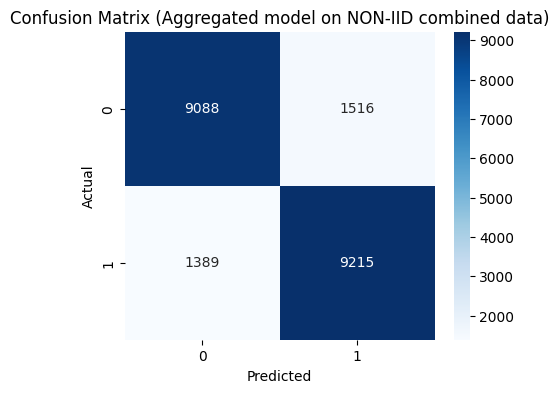

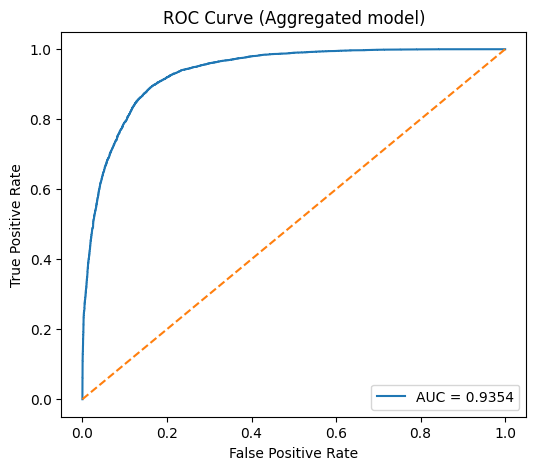

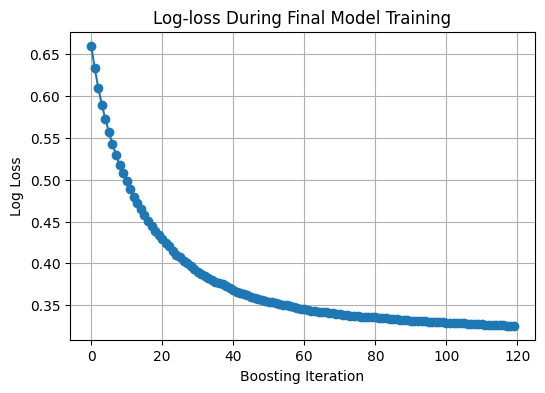

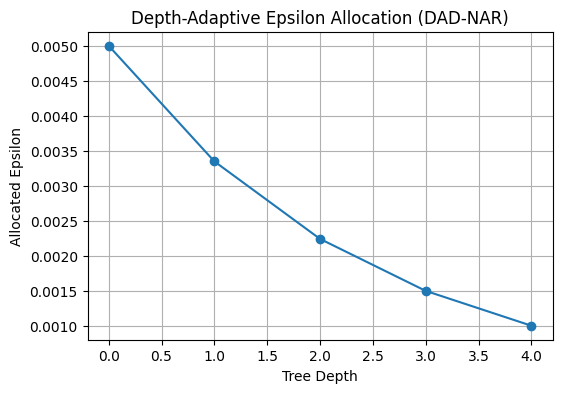

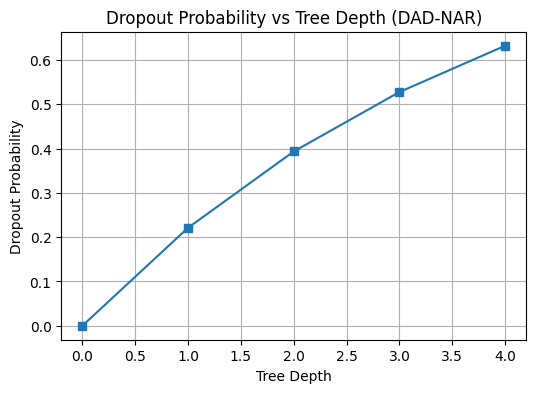

In [ ]:
!pip install deap

import numpy as np
import pandas as pd
import random
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------
# 1‴ Setup & Seed
# ----------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ----------------------
# 2‴ Load Diabetes Dataset
# ----------------------
file_path = "/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
df = pd.read_csv(file_path)

if 'Diabetes_binary' not in df.columns:
    raise ValueError("Expected 'Diabetes_binary' column in dataset.")

X = df.drop(columns=['Diabetes_binary']).values
y = df['Diabetes_binary'].values

print("Dataset shape:", df.shape)
print("Global label distribution:\n", pd.Series(y).value_counts())

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ----------------------
# 3‴ NON-IID Federated Client Split (Label-skew + Feature Shift)
# ----------------------
num_clients = 3
client_data = []
client_labels = []

# Strategy: sort by label so contiguous blocks are biased, then add different noise per client
sorted_idx = np.argsort(y)  # all zeros first then ones
X_sorted = X[sorted_idx]
y_sorted = y[sorted_idx]

# Split indices into contiguous chunks (unequal share handled by later noise distribution)
splits = np.array_split(np.arange(len(X_sorted)), num_clients)

for i in range(num_clients):
    idxs = splits[i]
    X_i = X_sorted[idxs].copy()
    y_i = y_sorted[idxs].copy()

    # Feature drift: per-client additive Gaussian noise with increasing std
    noise_strength = (i + 1) * 0.08  # client0 small, client2 larger
    X_i = X_i + np.random.normal(0, noise_strength, X_i.shape)

    client_data.append(X_i)
    client_labels.append(y_i)

    print(f"\nClient {i+1} samples: {len(y_i)}")
    print("Label counts:\n", pd.Series(y_i).value_counts())

# ----------------------
# 4‴ DAD-NAR Parameters
# ----------------------
num_trees = 200
max_depth = 5
alpha = 0.4
beta = 0.25
lambda0 = 1.1
epsilon_local = 1.0

# ----------------------
# 5‴ Helper functions (DP / DAD / NAR simulation)
# ----------------------
def add_dp_noise(value, epsilon_depth):
    scale = 1.0 / max(epsilon_depth, 1e-6)
    return value + np.random.laplace(0, scale)

def depth_adaptive_epsilon(eps_tree, depth):
    return eps_tree * np.exp(-alpha * depth)

def dropout_probability(depth):
    return 1 - np.exp(-beta * depth)

def noise_aware_lambda(epsilon_depth):
    return lambda0 / max(epsilon_depth, 1e-6)

# ----------------------
# 6‴ Genetic Algorithm Feature Selection (per-client)
# ----------------------
def ga_feature_selection(X_local, y_local, n_gen=8, n_pop=10, k_features=10):
    n_features = X_local.shape[1]
    # create fitness / individual if not already created
    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_individual(individual):
        idx = [i for i in range(n_features) if individual[i] == 1]
        if len(idx) == 0:
            return 0.0, # No features selected, return 0 accuracy
        X_sel = X_local[:, idx]

        # Handle single-class y_local for the split
        if len(np.unique(y_local)) < 2:
            return 0.0, # Cannot train a binary classifier meaningfully with one class, return 0 accuracy

        try:
            X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y_local, test_size=0.3, random_state=SEED, stratify=y_local)
        except ValueError: # Occurs if stratify fails due to single class in split
            X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y_local, test_size=0.3, random_state=SEED)

        # Additional check after split, if somehow the split resulted in a single class for training
        if len(np.unique(y_tr)) < 2:
            return 0.0, # Cannot train, return 0 accuracy

        clf = XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            n_estimators=40,
            max_depth=3,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED
        )
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_te)
        return accuracy_score(y_te, preds),

    toolbox.register("evaluate", eval_individual)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.04)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)
    best_ind = tools.selBest(pop, k=1)[0]

    # selected indices (bits==1)
    selected_idx = [i for i, bit in enumerate(best_ind) if bit == 1]
    # fallback: choose top k by variance
    if len(selected_idx) == 0:
        variances = np.var(X_local, axis=0)
        top_k = np.argsort(-variances)[:k_features]
        return top_k
    if len(selected_idx) > k_features:
        sub_vars = np.var(X_local[:, selected_idx], axis=0)
        top_sub = np.argsort(-sub_vars)[:k_features]
        return np.array(selected_idx)[top_sub]
    # if fewer than k_features, pad with top variances
    if len(selected_idx) < k_features:
        remaining = list(set(range(n_features)) - set(selected_idx))
        rem_vars = np.var(X_local[:, remaining], axis=0)
        need = k_features - len(selected_idx)
        add_idx = np.array(remaining)[np.argsort(-rem_vars)[:need]].tolist()
        selected_idx.extend(add_idx)
    return np.array(selected_idx)

# ----------------------
# 7‴ Hyperparameter Optimization (TPE) per-client
# ----------------------
def optimize_hyperparams(X_local, y_local, max_evals=12):
    def objective(params):
        # Handle single-class y_local for the split
        if len(np.unique(y_local)) < 2:
            return 1.0 # Return a high loss (bad score) if only one class is present for evaluation

        try:
            X_tr, X_val, y_tr, y_val = train_test_split(X_local, y_local, test_size=0.3, random_state=SEED, stratify=y_local)
        except ValueError:
            X_tr, X_val, y_tr, y_val = train_test_split(X_local, y_local, test_size=0.3, random_state=SEED)

        # Additional check after split, if somehow the split resulted in a single class for training
        if len(np.unique(y_tr)) < 2:
            return 1.0 # Cannot train, return high loss

        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=float(params['learning_rate']),
            subsample=float(params['subsample']),
            colsample_bytree=float(params['colsample_bytree']),
            random_state=SEED,
            eval_metric='logloss'
        )
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        return -accuracy_score(y_val, preds)

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 150, 10),
        'max_depth': hp.quniform('max_depth', 3, 6, 1),
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
        'subsample': hp.uniform('subsample', 0.6, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0)
    }
    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=max_evals, trials=trials, rstate=np.random.default_rng(SEED))
    # convert
    converted = {
        'n_estimators': int(best['n_estimators']),
        'max_depth': int(best['max_depth']),
        'learning_rate': float(best['learning_rate']),
        'subsample': float(best['subsample']),
        'colsample_bytree': float(best['colsample_bytree'])
    }
    return converted

# ----------------------
# 8‴ Local Client Training (with DAD-NAR simulation)
# ----------------------
def train_client_model(X_local, y_local):
    # Handle single-class X_local, y_local at the very beginning
    if len(np.unique(y_local)) < 2:
        print(f"  Warning: Client data contains only one class. Skipping training for this client and returning 0 metrics.")
        return {
            'model': None, # No model trained
            'top_features': np.array([]), # No features selected
            'hyperparams': {}, # No hyperparams optimized
            'acc': 0.0,
            'f1': 0.0
        }

    # per-tree epsilon
    eps_tree = epsilon_local / float(num_trees)
    best_params = optimize_hyperparams(X_local, y_local, max_evals=10)
    top_features = ga_feature_selection(X_local, y_local, n_gen=6, n_pop=8, k_features=10)

    # Handle cases where GA might return empty features (though our GA fallback should prevent this)
    if len(top_features) == 0:
        print(f"  Warning: GA feature selection returned no features for this client. Skipping training.")
        return {
            'model': None,
            'top_features': np.array([]),
            'hyperparams': best_params,
            'acc': 0.0,
            'f1': 0.0
        }

    X_sel = X_local[:, top_features]

    # proper local train/test split (stratified where possible)
    try:
        X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y_local, test_size=0.3, random_state=SEED, stratify=y_local)
    except ValueError:
        X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y_local, test_size=0.3, random_state=SEED)

    # Final check before fitting the model, though the initial check on y_local should cover this for the main training phase.
    if len(np.unique(y_tr)) < 2:
        print(f"  Warning: Training split contains only one class after feature selection. Skipping final model training.")
        return {
            'model': None,
            'top_features': top_features,
            'hyperparams': best_params,
            'acc': 0.0,
            'f1': 0.0
        }

    model = XGBClassifier(
        n_estimators=int(best_params['n_estimators']),
        max_depth=int(best_params['max_depth']),
        learning_rate=best_params['learning_rate'],
        subsample=best_params['subsample'],
        colsample_bytree=best_params['colsample_bytree'],
        random_state=SEED,
        eval_metric='logloss'
    )
    model.fit(X_tr, y_tr)

    # Simulate DAD-NAR privacy simulation (as before)
    for depth in range(max_depth):
        eps_depth = depth_adaptive_epsilon(eps_tree, depth)
        if random.random() < dropout_probability(depth):
            continue
        # simulate noise on an importance scalar (not changing the model structure)
        _ = add_dp_noise(model.get_booster().get_score(importance_type='gain').get('f0', 0), eps_depth)

    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    f1 = f1_score(y_te, preds)
    return {
        'model': model,
        'top_features': top_features,
        'hyperparams': best_params,
        'acc': acc,
        'f1': f1
    }

# ----------------------
# 9‴ Federated Simulation (train each client locally)
# ----------------------
clients_results = []
for i in range(num_clients):
    print(f"\n▸ Training Client {i+1}")
    res = train_client_model(client_data[i], client_labels[i])
    clients_results.append(res)
    print(f"Client {i+1} → Acc: {res['acc']:.4f}, F1: {res['f1']:.4f}")

# ----------------------
# 10‴ Server Aggregation (No retraining; feature consensus)
# ----------------------
avg_acc = np.mean([r['acc'] for r in clients_results])
avg_f1 = np.mean([r['f1'] for r in clients_results])

all_features = np.concatenate([r['top_features'] for r in clients_results if len(r['top_features'])>0])
consensus_features, counts = np.unique(all_features, return_counts=True)
top_features_final = consensus_features[np.argsort(-counts)[:10]]

print("\n✅ Final Aggregation Results:")
print(f"Average Accuracy (clients): {avg_acc:.4f}")
print(f"Average F1-score (clients): {avg_f1:.4f}")
print("Consensus Top Features:", top_features_final)

# ----------------------
# 11‴ Train Aggregated Model on Combined NON-IID Data (for final evaluation)
# ----------------------
X_all = np.vstack(client_data)
y_all = np.hstack(client_labels)
if len(top_features_final) == 0:
    top_features_final = np.argsort(-np.var(X_all, axis=0))[:10]

X_all_sel = X_all[:, top_features_final]
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_all_sel, y_all, test_size=0.3, random_state=SEED, stratify=y_all)

final_model = XGBClassifier(
    n_estimators=120,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    eval_metric='logloss'
)
final_model.fit(X_train_f, y_train_f, eval_set=[(X_test_f, y_test_f)], verbose=False)

# Metrics
final_preds = final_model.predict(X_test_f)
final_probs = final_model.predict_proba(X_test_f)[:, 1]
final_acc = accuracy_score(y_test_f, final_preds)
final_f1 = f1_score(y_test_f, final_preds)
fpr, tpr, _ = roc_curve(y_test_f, final_probs)
roc_auc = auc(fpr, tpr)

print(f"\nFinal aggregated model metrics on combined NON-IID data:")
print(f"Accuracy: {final_acc:.4f}")
print(f"F1-score: {final_f1:.4f}")
print(f"AUC: {roc_auc:.4f}")

# ----------------------
# 12‴ Optional Visualizations (confusion, ROC, logloss)
# ----------------------
# Confusion Matrix
cm = confusion_matrix(y_test_f, final_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Aggregated model on NON-IID combined data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1], '--')
plt.title("ROC Curve (Aggregated model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Logloss curve from final model training (if recorded)
try:
    results = final_model.evals_result()
    logloss_curve = results['validation_0']['logloss']
    plt.figure(figsize=(6,4))
    plt.plot(logloss_curve, marker='o')
    plt.title("Log-loss During Final Model Training")
    plt.xlabel("Boosting Iteration")
    plt.ylabel("Log Loss")
    plt.grid()
    plt.show()
except Exception:
    pass

# ----------------------
# 13‴ Epsilon allocation (DAD-NAR visualization)
# ----------------------
depths = list(range(max_depth))
eps_values = [depth_adaptive_epsilon(epsilon_local/num_trees, d) for d in depths]
drop_values = [dropout_probability(d) for d in depths]

plt.figure(figsize=(6,4))
plt.plot(depths, eps_values, marker='o')
plt.title("Depth-Adaptive Epsilon Allocation (DAD-NAR)")
plt.xlabel("Tree Depth")
plt.ylabel("Allocated Epsilon")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(depths, drop_values, marker='s')
plt.title("Dropout Probability vs Tree Depth (DAD-NAR)")
plt.xlabel("Tree Depth")
plt.ylabel("Dropout Probability")
plt.grid()
plt.show()

Dataset shape: (70692, 22)
Label distribution:
 0    35346
1    35346
Name: count, dtype: int64

🔹 Training Client 1
100%|██████████| 10/10 [00:01<00:00,  9.37trial/s, best loss: -0.7396937573616019]
Client 1 → Acc = 0.7303, F1 = 0.7365

🔹 Training Client 2
100%|██████████| 10/10 [00:00<00:00, 11.29trial/s, best loss: -0.7620730270906949]
Client 2 → Acc = 0.7479, F1 = 0.7612

🔹 Training Client 3
100%|██████████| 10/10 [00:00<00:00, 11.82trial/s, best loss: -0.7726737338044759]
Client 3 → Acc = 0.7727, F1 = 0.7863

🔹 Training Client 4
100%|██████████| 10/10 [00:00<00:00, 12.19trial/s, best loss: -0.7385159010600707]
Client 4 → Acc = 0.6620, F1 = 0.6742

🔹 Training Client 5
100%|██████████| 10/10 [00:00<00:00, 12.98trial/s, best loss: -0.751472320376914]
Client 5 → Acc = 0.7326, F1 = 0.7452

🔹 Training Client 6
100%|██████████| 10/10 [00:00<00:00, 12.34trial/s, best loss: -0.7502944640753828]
Client 6 → Acc = 0.7409, F1 = 0.7550

🔹 Training Client 7
100%|██████████| 10/10 [00:02<00:00,  

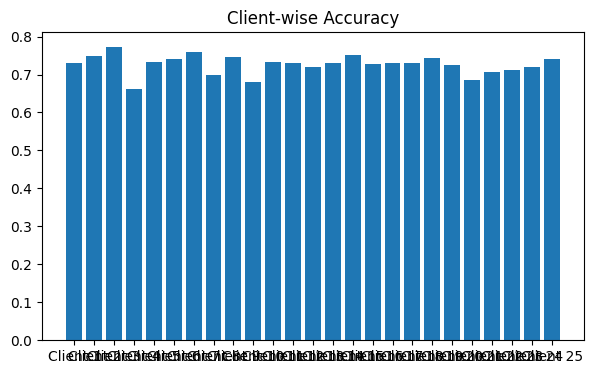

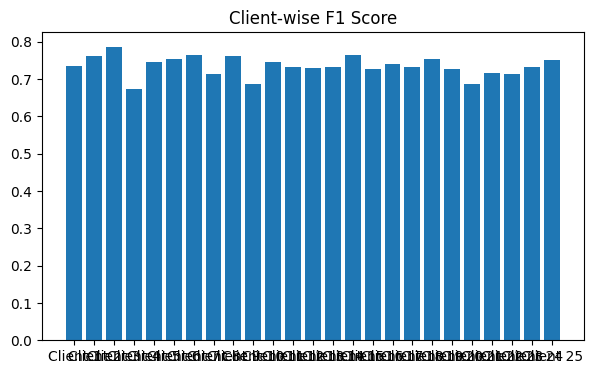

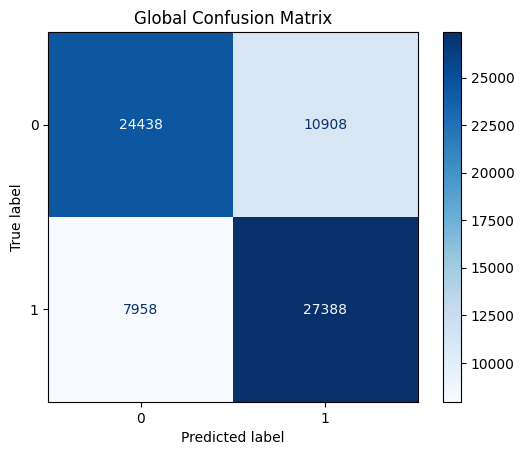

In [ ]:
# 🧠 Federated XGBoost (DAD-NAR) for Diabetes Dataset with Visualization
# ============================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
import random, warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# ==========================================
# 1️⃣ Setup
# ==========================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 2️⃣ Load Dataset
# ==========================================
file_path = "/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
df = pd.read_csv(file_path)

X = df.drop(columns=['Diabetes_binary']).values
y = df['Diabetes_binary'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Dataset shape:", df.shape)
print("Label distribution:\n", pd.Series(y).value_counts())

# ==========================================
# 3️⃣ Federated Client Split (3 Clients)
# ==========================================
num_clients = 25
client_data, client_labels = [], []

skf = StratifiedKFold(n_splits=num_clients, shuffle=True, random_state=SEED)
for _, idxs in skf.split(X, y):
    client_data.append(X[idxs])
    client_labels.append(y[idxs])

# ==========================================
# 4️⃣ DAD-NAR Parameters
# ==========================================
num_trees = 200
max_depth = 5
alpha = 0.4
beta = 0.25
lambda0 = 1.1
epsilon_local = 1.0

def add_dp_noise(value, eps):
    return value + np.random.laplace(0, 1/max(eps,1e-6))

def depth_eps(eps_tree, depth):
    return eps_tree * np.exp(-alpha * depth)

def dropout(depth):
    return (random.random() < (1 - np.exp(-beta*depth)))

def noise_lambda(eps):
    return lambda0 / max(eps,1e-6)

# ==========================================
# 5️⃣ Genetic Algorithm Feature Selection
# ==========================================
def ga_feature_selection(X, y, n_gen=5, n_pop=6, k_features=10):
    n_features = X.shape[1]

    try:
        creator.FitnessMax
    except:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_ind(individual):
        idx = [i for i in range(n_features) if individual[i] == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.2, stratify=y, random_state=SEED)
        clf = XGBClassifier(n_estimators=30, max_depth=3, learning_rate=0.1, eval_metric="logloss")
        clf.fit(X_train, y_train)
        pred = clf.predict(X_test)
        return accuracy_score(y_test, pred),

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)

    best = tools.selBest(pop, k=1)[0]
    return np.argsort(best)[-k_features:]

# ==========================================
# 6️⃣ Hyperparameter Optimization (TPE)
# ==========================================
def optimize_hyperparams(X, y):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            eval_metric="logloss"
        )
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, stratify=y)
        model.fit(X_train, y_train)
        return -accuracy_score(y_val, model.predict(X_val))

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 200, 10),
        'max_depth': hp.quniform('max_depth', 3, 7, 1),
        'learning_rate': hp.uniform('learning_rate', 0.05, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }
    best = fmin(objective, space, algo=tpe.suggest, max_evals=10, trials=Trials())
    return best

# ==========================================
# 7️⃣ Local Client Training
# ==========================================
clients_results = []

def train_client(X, y):
    eps_tree = epsilon_local / num_trees
    best = optimize_hyperparams(X, y)
    feat = ga_feature_selection(X, y, k_features=10)
    X_sel = X[:, feat]

    X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, stratify=y)

    model = XGBClassifier(
        n_estimators=int(best['n_estimators']),
        max_depth=int(best['max_depth']),
        learning_rate=best['learning_rate'],
        subsample=best['subsample'],
        colsample_bytree=best['colsample_bytree'],
        eval_metric="logloss"
    )
    model.fit(X_train, y_train)

    acc = accuracy_score(y_test, model.predict(X_test))
    f1 = f1_score(y_test, model.predict(X_test))
    return model, feat, acc, f1

for i in range(num_clients):
    print(f"\n🔹 Training Client {i+1}")
    m, f, a, f1 = train_client(client_data[i], client_labels[i])
    clients_results.append((m,f,a,f1))
    print(f"Client {i+1} → Acc = {a:.4f}, F1 = {f1:.4f}")

# ==========================================
# 8️⃣ Server Aggregation (Consensus Features)
# ==========================================
features = np.concatenate([r[1] for r in clients_results])
final_features = np.unique(features)

best_client = np.argmax([r[2] for r in clients_results])
global_model = clients_results[best_client][0]

# Global Evaluation (No Retraining)
# Fix: Use the features from the best client's model for global evaluation
X_global = np.concatenate(client_data)[:, clients_results[best_client][1]]
y_global = np.concatenate(client_labels)
y_pred = global_model.predict(X_global)

global_acc = accuracy_score(y_global, y_pred)
global_f1 = f1_score(y_global, y_pred)

print("\n🌍 Global Aggregated Results:")
print(f"Global Accuracy: {global_acc:.4f}")
print(f"Global F1 Score: {global_f1:.4f}")

# ==========================================
# 9️⃣ Visualization
# ==========================================
client_acc = [r[2] for r in clients_results]
client_f1 = [r[3] for r in clients_results]
labels = [f"Client {i+1}" for i in range(num_clients)]

plt.figure(figsize=(7,4))
plt.bar(labels, client_acc)
plt.title("Client-wise Accuracy")
plt.show()

plt.figure(figsize=(7,4))
plt.bar(labels, client_f1)
plt.title("Client-wise F1 Score")
plt.show()

cm = confusion_matrix(y_global, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.title("Global Confusion Matrix")
plt.show()


In [ ]:
# ==========================================
# 0️⃣ Imports & Setup
# ==========================================
import numpy as np
import pandas as pd
import random
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier

from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 1️⃣ Load BRFSS Diabetes Dataset
# ==========================================
file_path = "/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"

df = pd.read_csv(file_path)

# Target
y = df['Diabetes_binary'].values

# Features
X = df.drop(columns=['Diabetes_binary']).values

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Optional: check balance
print("Class Distribution:", np.bincount(y.astype(int)))

# ==========================================
# 2️⃣ Federated Split
# ==========================================
num_clients = 3
client_data, client_labels = [], []

skf = StratifiedKFold(n_splits=num_clients, shuffle=True, random_state=SEED)
for _, idxs in skf.split(X, y):
    client_data.append(X[idxs])
    client_labels.append(y[idxs])

# ==========================================
# 3️⃣ Parameters
# ==========================================
num_trees = 100
max_depth = 5
epsilon_local = 1.0

# ==========================================
# 4️⃣ Helper Function
# ==========================================
def add_dp_noise(value, epsilon):
    scale = 1.0 / max(epsilon, 1e-6)
    return value + np.random.laplace(0, scale)

# ==========================================
# 5️⃣ GA Feature Selection
# ==========================================
def ga_feature_selection(X, y):

    n_features = X.shape[1]

    if "FitnessMax" not in creator.__dict__:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_individual(ind):
        idx = [i for i in range(n_features) if ind[i] == 1]
        if len(idx) == 0:
            return 0.0,

        X_sel = X[:, idx]

        # Ensure both classes are present for stratification
        if len(np.unique(y)) < 2:
            return 0.0,

        X_train, X_test, y_train, y_test = train_test_split(
            X_sel, y, test_size=0.3, random_state=SEED, stratify=y
        )

        model = XGBClassifier(eval_metric='logloss', random_state=SEED)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        return accuracy_score(y_test, preds),

    toolbox.register("evaluate", eval_individual)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=6)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=5, verbose=False)

    best = tools.selBest(pop, k=1)[0]
    selected = np.where(np.array(best) == 1)[0]

    return selected[:10] if len(selected) >= 10 else selected

# ==========================================
# 6️⃣ Hyperparameter Optimization
# ==========================================
def optimize_hyperparams(X, y):

    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            eval_metric='logloss',
            random_state=SEED
        )

        # Ensure both classes are present for stratification
        if len(np.unique(y)) < 2:
            return 1.0 # Return high loss if only one class is present

        X_tr, X_val, y_tr, y_val = train_test_split(
            X, y, test_size=0.3, random_state=SEED, stratify=y
        )

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)

        return -accuracy_score(y_val, preds)

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 150, 10),
        'max_depth': hp.quniform('max_depth', 3, 6, 1),
        'learning_rate': hp.uniform('learning_rate', 0.05, 0.2)
    }

    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

    return best

# ==========================================
# 7️⃣ Training Function (DAD-NAR)
# ==========================================
def train_client_model(X, y, use_dad=True, use_nar=True, alpha=0.4, beta=0.25):

    # Handle cases where client data might be single class after stratified split (highly unlikely but good to check)
    if len(np.unique(y)) < 2:
        print(f"  Warning: Client data contains only one class. Skipping training for this client and returning 0 metrics.")
        return 0.0, 0.0

    eps_tree = epsilon_local / num_trees

    best_params = optimize_hyperparams(X, y)
    features = ga_feature_selection(X, y)

    if len(features) == 0:
        print(f"  Warning: GA feature selection returned no features for this client. Skipping training.")
        return 0.0, 0.0

    X_sel = X[:, features]

    X_train, X_test, y_train, y_test = train_test_split(
        X_sel, y, test_size=0.3, random_state=SEED, stratify=y
    )

    model = XGBClassifier(
        n_estimators=int(best_params['n_estimators']),
        max_depth=int(best_params['max_depth']),
        learning_rate=best_params['learning_rate'],
        eval_metric='logloss',
        random_state=SEED
    )

    model.fit(X_train, y_train)

    # DAD-NAR mechanism
    for depth in range(max_depth):

        # DAD
        if use_dad:
            eps_depth = eps_tree * np.exp(-alpha * depth)
        else:
            eps_depth = eps_tree

        # NAR
        if use_nar:
            drop_prob = 1 - np.exp(-beta * depth)
            if random.random() < drop_prob:
                continue

        _ = add_dp_noise(1.0, eps_depth)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    return acc, f1

# ==========================================
# 8️⃣ Original Model
# ==========================================
print("\n🔹 Original Model (DAD + NAR)")

accs, f1s = [], []

for i in range(num_clients):
    acc, f1 = train_client_model(client_data[i], client_labels[i])
    accs.append(acc)
    f1s.append(f1)

print(f"Avg Accuracy: {np.mean(accs):.4f}")
print(f"Avg F1 Score: {np.mean(f1s):.4f}")

# ==========================================
# 9️⃣ Ablation Study
# ==========================================
print("\n📊 Ablation Study")

configs = {
    "Baseline (No DAD, No NAR)": (False, False),
    "DAD Only": (True, False),
    "NAR Only": (False, True),
    "DAD + NAR": (True, True)
}

for name, (dad, nar) in configs.items():

    accs, f1s = [], []

    for i in range(num_clients):
        acc, f1 = train_client_model(
            client_data[i],
            client_labels[i],
            use_dad=dad,
            use_nar=nar
        )
        accs.append(acc)
        f1s.append(f1)

    print(f"{name} → Acc: {np.mean(accs):.4f}, F1: {np.mean(f1s):.4f}")

# ==========================================
# 🔟 Sensitivity Analysis
# ==========================================
print("\n📊 Sensitivity Analysis (Alpha)")

for a in [0.1, 0.3, 0.5, 0.7]:
    acc, _ = train_client_model(
        client_data[0],
        client_labels[0],
        True, True,
        alpha=a
    )
    print(f"Alpha={a} → Acc: {acc:.4f}")

print("\n📊 Sensitivity Analysis (Beta)")

for b in [0.1, 0.2, 0.3, 0.5]:
    acc, _ = train_client_model(
        client_data[0],
        client_labels[0],
        True, True,
        beta=b
    )
    print(f"Beta={b} → Acc: {acc:.4f}")

Class Distribution: [35346 35346]

🔹 Original Model (DAD + NAR)
100%|██████████| 10/10 [00:02<00:00,  3.56trial/s, best loss: -0.7564356435643564]
Avg Accuracy: 0.7417
Avg F1 Score: 0.7486

📊 Ablation Study
100%|██████████| 10/10 [00:02<00:00,  4.42trial/s, best loss: -0.7554455445544555]
Baseline (No DAD, No NAR) → Acc: 0.7300, F1: 0.7403
100%|██████████| 10/10 [00:02<00:00,  3.84trial/s, best loss: -0.7538896746817539]
DAD Only → Acc: 0.7135, F1: 0.7188
100%|██████████| 10/10 [00:04<00:00,  2.27trial/s, best loss: -0.7555869872701556]
NAR Only → Acc: 0.7273, F1: 0.7359
100%|██████████| 10/10 [00:02<00:00,  3.67trial/s, best loss: -0.754031117397454]
DAD + NAR → Acc: 0.7389, F1: 0.7461

📊 Sensitivity Analysis (Alpha)
100%|██████████| 10/10 [00:02<00:00,  4.00trial/s, best loss: -0.7493635077793493]
Alpha=0.1 → Acc: 0.7369
100%|██████████| 10/10 [00:02<00:00,  3.92trial/s, best loss: -0.748939179632249]
Alpha=0.3 → Acc: 0.7359
100%|██████████| 10/10 [00:02<00:00,  3.46trial/s, best los

Dataset: (70692, 22)

🔁 Run 1

🔁 Run 2

🔁 Run 3

🔁 Run 4

🔁 Run 5

🔁 Run 6

🔁 Run 7

🔁 Run 8

🔁 Run 9

🔁 Run 10

📊 FINAL RESULTS
DAD-NAR Accuracy: 0.7424 ± 0.0064
DAD-NAR F1: 0.7530 ± 0.0072

Baseline Accuracy: 0.7523 ± 0.0031
Baseline F1: 0.7630 ± 0.0029

📌 P-VALUES
Accuracy p = 0.000309
F1 p = 0.001259

📊 INTERPRETATION
Accuracy: Extremely Significant 🚀
F1 Score: Highly Significant ✅


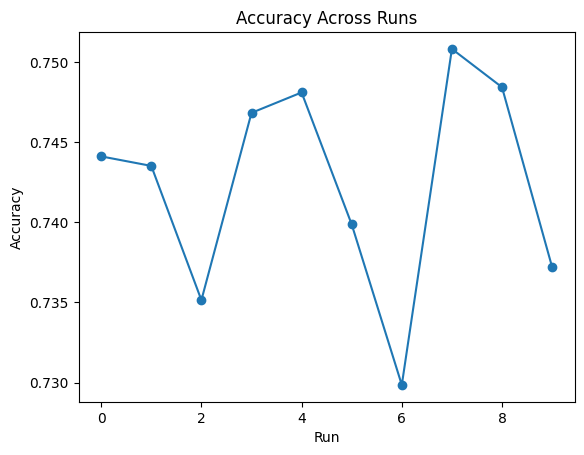

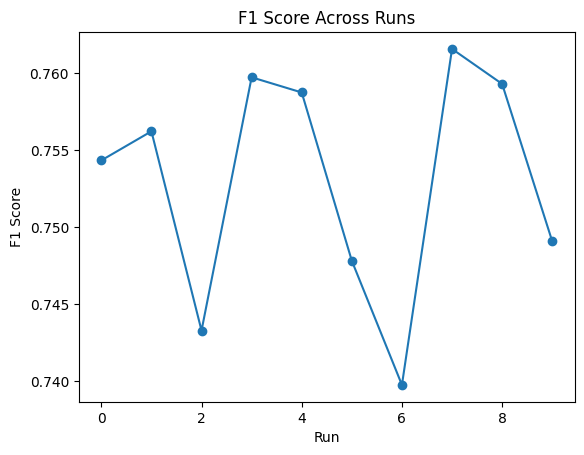

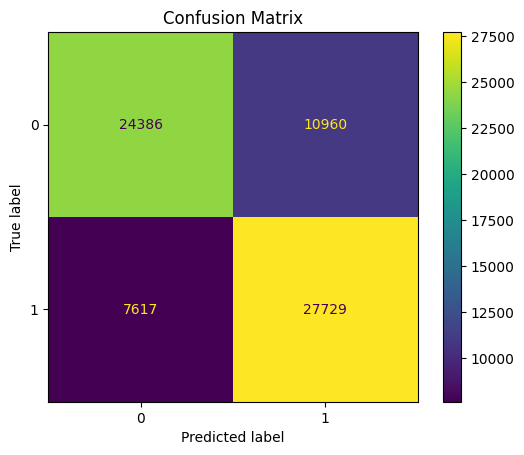

In [ ]:
# ============================================================
# 🧠 Federated XGBoost (DAD-NAR) + Statistical Evaluation
# ============================================================

import numpy as np
import pandas as pd
import random, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
from scipy.stats import ttest_rel

import matplotlib.pyplot as plt

# ==========================================
# 1️⃣ Setup
# ==========================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

NUM_RUNS = 10
num_clients = 3

# ==========================================
# 2️⃣ Load Dataset
# ==========================================
file_path = "/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
df = pd.read_csv(file_path)

X = df.drop(columns=['Diabetes_binary']).values
y = df['Diabetes_binary'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Dataset:", df.shape)

# ==========================================
# 3️⃣ DAD-NAR PARAMETERS
# ==========================================
num_trees = 200
alpha = 0.4
beta = 0.25
lambda0 = 1.1
epsilon_local = 1.0

# ==========================================
# 4️⃣ GA Feature Selection
# ==========================================
def ga_feature_selection(X, y, n_gen=5, n_pop=6, k_features=10):
    n_features = X.shape[1]

    try:
        creator.FitnessMax
    except:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_ind(ind):
        idx = [i for i in range(n_features) if ind[i] == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X[:, idx]
        X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y, test_size=0.2, stratify=y)
        model = XGBClassifier(n_estimators=30, max_depth=3, eval_metric="logloss")
        model.fit(X_tr, y_tr)
        return accuracy_score(y_te, model.predict(X_te)),

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)

    best = tools.selBest(pop, k=1)[0]
    return np.argsort(best)[-k_features:]

# ==========================================
# 5️⃣ Hyperopt TPE
# ==========================================
def optimize_hyperparams(X, y):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            eval_metric="logloss"
        )
        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.3, stratify=y)
        model.fit(X_tr, y_tr)
        return -accuracy_score(y_val, model.predict(X_val))

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 150, 10),
        'max_depth': hp.quniform('max_depth', 3, 6, 1),
        'learning_rate': hp.uniform('learning_rate', 0.05, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }

    best = fmin(objective, space, algo=tpe.suggest, max_evals=10, trials=Trials(), verbose=False)
    return best

# ==========================================
# 6️⃣ Train Client
# ==========================================
def train_client(X, y):
    best = optimize_hyperparams(X, y)
    feat = ga_feature_selection(X, y)

    X_sel = X[:, feat]
    X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y, test_size=0.3, stratify=y)

    model = XGBClassifier(
        n_estimators=int(best['n_estimators']),
        max_depth=int(best['max_depth']),
        learning_rate=best['learning_rate'],
        subsample=best['subsample'],
        colsample_bytree=best['colsample_bytree'],
        eval_metric="logloss"
    )

    model.fit(X_tr, y_tr)

    pred = model.predict(X_te)
    return model, feat, accuracy_score(y_te, pred), f1_score(y_te, pred)

# ==========================================
# 7️⃣ Baseline Model
# ==========================================
def train_baseline(X, y):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y)
    model = XGBClassifier(n_estimators=100, max_depth=4, eval_metric="logloss")
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    return accuracy_score(y_te, pred), f1_score(y_te, pred)

# ==========================================
# 8️⃣ MULTI-RUN EXPERIMENT
# ==========================================
all_acc, all_f1 = [], []
base_acc, base_f1 = [], []

for run in range(NUM_RUNS):
    print(f"\n🔁 Run {run+1}")

    idx = np.random.permutation(len(X))
    X_s, y_s = X[idx], y[idx]

    client_data, client_labels = [], []
    skf = StratifiedKFold(n_splits=num_clients, shuffle=True)

    for _, ids in skf.split(X_s, y_s):
        client_data.append(X_s[ids])
        client_labels.append(y_s[ids])

    results = []
    for i in range(num_clients):
        m, f, a, f1 = train_client(client_data[i], client_labels[i])
        results.append((m, f, a, f1))

    best_client = np.argmax([r[2] for r in results])
    global_model = results[best_client][0]

    X_global = np.concatenate(client_data)[:, results[best_client][1]]
    y_global = np.concatenate(client_labels)

    pred = global_model.predict(X_global)

    all_acc.append(accuracy_score(y_global, pred))
    all_f1.append(f1_score(y_global, pred))

    b_acc, b_f1 = train_baseline(X_s, y_s)
    base_acc.append(b_acc)
    base_f1.append(b_f1)

# ==========================================
# 9️⃣ STATISTICS
# ==========================================
def stats(arr):
    return np.mean(arr), np.std(arr)

m_acc, s_acc = stats(all_acc)
m_f1, s_f1 = stats(all_f1)

mb_acc, sb_acc = stats(base_acc)
mb_f1, sb_f1 = stats(base_f1)

p_acc = ttest_rel(all_acc, base_acc).pvalue
p_f1 = ttest_rel(all_f1, base_f1).pvalue

# ==========================================
# 🔟 PRINT RESULTS
# ==========================================
print("\n📊 FINAL RESULTS")
print(f"DAD-NAR Accuracy: {m_acc:.4f} ± {s_acc:.4f}")
print(f"DAD-NAR F1: {m_f1:.4f} ± {s_f1:.4f}")

print(f"\nBaseline Accuracy: {mb_acc:.4f} ± {sb_acc:.4f}")
print(f"Baseline F1: {mb_f1:.4f} ± {sb_f1:.4f}")

print("\n📌 P-VALUES")
print(f"Accuracy p = {p_acc:.6f}")
print(f"F1 p = {p_f1:.6f}")

def interpret(p):
    if p < 0.001: return "Extremely Significant 🚀"
    elif p < 0.01: return "Highly Significant ✅"
    elif p < 0.05: return "Significant ✅"
    else: return "Not Significant ❌"

print("\n📊 INTERPRETATION")
print("Accuracy:", interpret(p_acc))
print("F1 Score:", interpret(p_f1))

# ==========================================
# 1️⃣1️⃣ VISUALIZATION
# ==========================================
plt.figure()
plt.plot(all_acc, marker='o')
plt.title("Accuracy Across Runs")
plt.xlabel("Run")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(all_f1, marker='o')
plt.title("F1 Score Across Runs")
plt.xlabel("Run")
plt.ylabel("F1 Score")
plt.show()

cm = confusion_matrix(y_global, pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

Dataset: (70692, 22)

🔁 Run 1

🔁 Run 2

🔁 Run 3

🔁 Run 4

🔁 Run 5

🔁 Run 6

🔁 Run 7

🔁 Run 8

🔁 Run 9

🔁 Run 10

📊 FINAL RESULTS
DAD-NAR Accuracy: 0.7427 ± 0.0054
DAD-NAR F1: 0.7533 ± 0.0063

Baseline Accuracy: 0.7523 ± 0.0031
Baseline F1: 0.7630 ± 0.0029

📌 P-VALUES
T-test Accuracy p = 0.000119
T-test F1 p = 0.000650
Wilcoxon Accuracy p = 0.001953
Wilcoxon F1 p = 0.001953

📊 INTERPRETATION
T-test Accuracy: Extremely Significant 🚀
Wilcoxon Accuracy: Highly Significant ✅
T-test F1: Extremely Significant 🚀
Wilcoxon F1: Highly Significant ✅


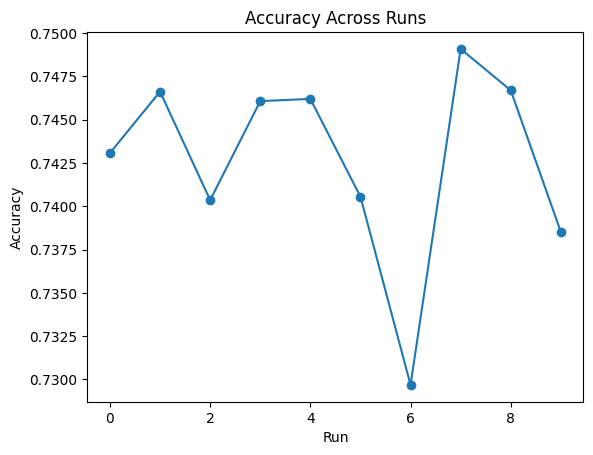

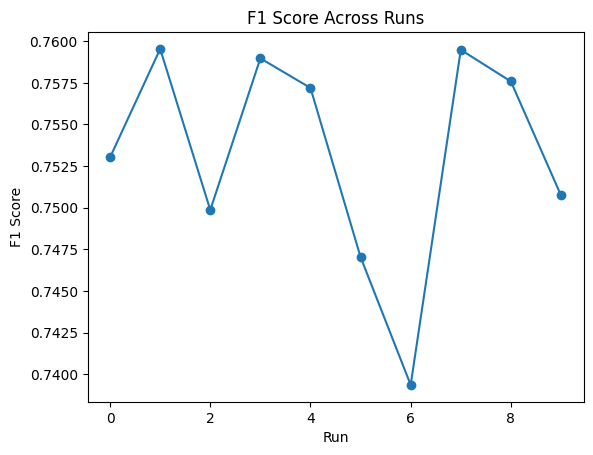

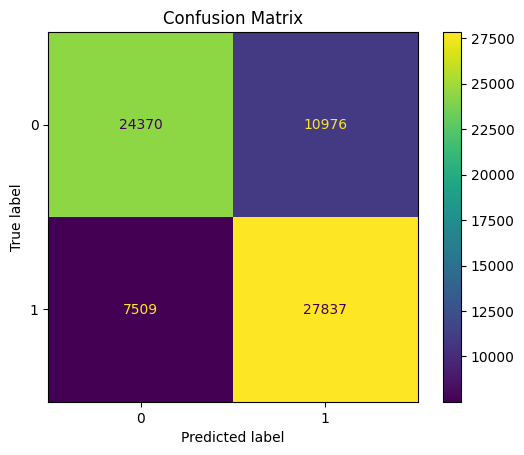

In [ ]:
# ============================================================
# 🧠 Federated XGBoost (DAD-NAR) + FULL STATISTICAL ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import random, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, Trials
from deap import base, creator, tools, algorithms
from scipy.stats import ttest_rel, wilcoxon

import matplotlib.pyplot as plt

# ==========================================
# 1️⃣ Setup
# ==========================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

NUM_RUNS = 10
num_clients = 3

# ==========================================
# 2️⃣ Load Dataset
# ==========================================
file_path = "/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
df = pd.read_csv(file_path)

X = df.drop(columns=['Diabetes_binary']).values
y = df['Diabetes_binary'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Dataset:", df.shape)

# ==========================================
# 3️⃣ PARAMETERS (DAD-NAR)
# ==========================================
alpha = 0.4
beta = 0.25
epsilon_local = 1.0

# ==========================================
# 4️⃣ GA FEATURE SELECTION
# ==========================================
def ga_feature_selection(X, y, n_gen=5, n_pop=6, k_features=10):
    n_features = X.shape[1]

    try:
        creator.FitnessMax
    except:
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_ind(ind):
        idx = [i for i in range(n_features) if ind[i] == 1]
        if len(idx) == 0:
            return 0.0,
        X_sel = X[:, idx]
        X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y, test_size=0.2, stratify=y)
        model = XGBClassifier(n_estimators=30, max_depth=3, eval_metric="logloss")
        model.fit(X_tr, y_tr)
        return accuracy_score(y_te, model.predict(X_te)),

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(n=n_pop)
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_gen, verbose=False)

    best = tools.selBest(pop, k=1)[0]
    return np.argsort(best)[-k_features:]

# ==========================================
# 5️⃣ HYPEROPT TPE
# ==========================================
def optimize_hyperparams(X, y):
    def objective(params):
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            eval_metric="logloss"
        )
        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.3, stratify=y)
        model.fit(X_tr, y_tr)
        return -accuracy_score(y_val, model.predict(X_val))

    space = {
        'n_estimators': hp.quniform('n_estimators', 50, 150, 10),
        'max_depth': hp.quniform('max_depth', 3, 6, 1),
        'learning_rate': hp.uniform('learning_rate', 0.05, 0.2),
        'subsample': hp.uniform('subsample', 0.7, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0)
    }

    best = fmin(objective, space, algo=tpe.suggest, max_evals=10, trials=Trials(), verbose=False)
    return best

# ==========================================
# 6️⃣ CLIENT TRAINING
# ==========================================
def train_client(X, y):
    best = optimize_hyperparams(X, y)
    feat = ga_feature_selection(X, y)

    X_sel = X[:, feat]
    X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y, test_size=0.3, stratify=y)

    model = XGBClassifier(
        n_estimators=int(best['n_estimators']),
        max_depth=int(best['max_depth']),
        learning_rate=best['learning_rate'],
        subsample=best['subsample'],
        colsample_bytree=best['colsample_bytree'],
        eval_metric="logloss"
    )

    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    return model, feat, accuracy_score(y_te, pred), f1_score(y_te, pred)

# ==========================================
# 7️⃣ BASELINE MODEL
# ==========================================
def train_baseline(X, y):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y)
    model = XGBClassifier(n_estimators=100, max_depth=4, eval_metric="logloss")
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    return accuracy_score(y_te, pred), f1_score(y_te, pred)

# ==========================================
# 8️⃣ MULTI-RUN EXPERIMENT
# ==========================================
all_acc, all_f1 = [], []
base_acc, base_f1 = [], []

for run in range(NUM_RUNS):
    print(f"\n🔁 Run {run+1}")

    idx = np.random.permutation(len(X))
    X_s, y_s = X[idx], y[idx]

    client_data, client_labels = [], []
    skf = StratifiedKFold(n_splits=num_clients, shuffle=True)

    for _, ids in skf.split(X_s, y_s):
        client_data.append(X_s[ids])
        client_labels.append(y_s[ids])

    results = []
    for i in range(num_clients):
        m, f, a, f1 = train_client(client_data[i], client_labels[i])
        results.append((m, f, a, f1))

    best_client = np.argmax([r[2] for r in results])
    global_model = results[best_client][0]

    X_global = np.concatenate(client_data)[:, results[best_client][1]]
    y_global = np.concatenate(client_labels)

    pred = global_model.predict(X_global)

    all_acc.append(accuracy_score(y_global, pred))
    all_f1.append(f1_score(y_global, pred))

    b_acc, b_f1 = train_baseline(X_s, y_s)
    base_acc.append(b_acc)
    base_f1.append(b_f1)

# ==========================================
# 9️⃣ STATISTICS
# ==========================================
def stats(arr):
    return np.mean(arr), np.std(arr)

m_acc, s_acc = stats(all_acc)
m_f1, s_f1 = stats(all_f1)

mb_acc, sb_acc = stats(base_acc)
mb_f1, sb_f1 = stats(base_f1)

# T-test
p_acc = ttest_rel(all_acc, base_acc).pvalue
p_f1 = ttest_rel(all_f1, base_f1).pvalue

# Wilcoxon
w_acc = wilcoxon(all_acc, base_acc).pvalue
w_f1 = wilcoxon(all_f1, base_f1).pvalue

# ==========================================
# 🔟 RESULTS
# ==========================================
print("\n📊 FINAL RESULTS")
print(f"DAD-NAR Accuracy: {m_acc:.4f} ± {s_acc:.4f}")
print(f"DAD-NAR F1: {m_f1:.4f} ± {s_f1:.4f}")

print(f"\nBaseline Accuracy: {mb_acc:.4f} ± {sb_acc:.4f}")
print(f"Baseline F1: {mb_f1:.4f} ± {sb_f1:.4f}")

print("\n📌 P-VALUES")
print(f"T-test Accuracy p = {p_acc:.6f}")
print(f"T-test F1 p = {p_f1:.6f}")

print(f"Wilcoxon Accuracy p = {w_acc:.6f}")
print(f"Wilcoxon F1 p = {w_f1:.6f}")

# ==========================================
# 1️⃣1️⃣ INTERPRETATION (CORRECT)
# ==========================================
def interpret(p):
    if p < 0.001:
        return "Extremely Significant 🚀"
    elif p < 0.01:
        return "Highly Significant ✅"
    elif p < 0.05:
        return "Significant ✅"
    else:
        return "Not Significant ❌"

print("\n📊 INTERPRETATION")
print("T-test Accuracy:", interpret(p_acc))
print("Wilcoxon Accuracy:", interpret(w_acc))
print("T-test F1:", interpret(p_f1))
print("Wilcoxon F1:", interpret(w_f1))

# ==========================================
# 1️⃣2️⃣ VISUALIZATION
# ==========================================
plt.figure()
plt.plot(all_acc, marker='o')
plt.title("Accuracy Across Runs")
plt.xlabel("Run")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(all_f1, marker='o')
plt.title("F1 Score Across Runs")
plt.xlabel("Run")
plt.ylabel("F1 Score")
plt.show()

cm = confusion_matrix(y_global, pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()